# Single Optical Flow Multi-Scale Pyramid Motion Detection
## With Temporal EMA, Track Coasting & Multi-Hypothesis Detection

This notebook implements **single optical flow with multi-scale pyramid processing**, **temporal EMA**, **Track Coasting**, and **Multi-Hypothesis Detection** for robust motion detection.

## Architecture
```
Frame → Upscale 1.5x → Optical Flow → Homography → Residual (1.5x)
                                                        │
                                                   ┌────┴────┐
                                                   │  EMA    │
                                                   │ Accum   │  ← Exponential Moving Average
                                                   │ (α=0.4) │    No buffer needed
                                                   └────┬────┘
                                                        │
                                              Accumulated Residual
                                                        │
                              ┌─────────────────────────┤
                              │                         │
                         Detect @ 1.5x            Downscale
                         (small objects)          
                         [Multi-Hypothesis]           │
                              ┌─────────────────────────┤
                              │                         │
                         Detect @ 1.0x            Downscale  
                         (medium objects)         
                         [Multi-Hypothesis]           │
                                                   Detect @ 0.5x
                                                   (large objects)
                                                   [Multi-Hypothesis]
                                                        │
                                                   NMS Merge
                                                        │
                                               ┌────────┴────────┐
                                               │  Track Manager  │
                                               │ • Kalman Filter │
                                               │ • Hungarian Alg │
                                               │ • Track Coasting│
                                               └────────┬────────┘
                                                        │
                                                   Output Tracks
                                            (with IDs, status, velocity)
```

## Key Features

### 1. Single Optical Flow (1.5x)
- OF computed at 1.5x resolution for better small object detection
- Single computation is cheaper than dual OF approach

### 2. Temporal EMA Smoothing
```
EMA_t = α × Residual_t + (1-α) × EMA_{t-1}

α = 0.4 (weight for new frame)
├─ High α (0.7-0.9): More responsive, follows changes quickly
├─ Medium α (0.4-0.6): Balanced smoothing
└─ Low α (0.2-0.3): Very smooth, slow to react
```
- Memory efficient - only stores single accumulated frame
- Tunable response with single parameter (α)

### 3. Track Coasting (NEW)
Keeps tracks alive during brief detection failures:
- **Kalman Filter**: Predicts positions when detection fails
- **Hungarian Algorithm**: Optimal detection-to-track matching
- **Track Lifecycle**: `tentative → confirmed → coasting → deleted`
- **Coast up to 10 frames** without detection

### 4. Multi-Hypothesis Detection (NEW)
Runs detection at multiple sigma thresholds:
- **Sigma levels**: [2.0, 2.5, 3.0, 3.5, 4.0]
- Objects detected at multiple sigmas get higher confidence
- Helps recover missed detections

### 5. Multi-Scale Pyramid
- **1.5x**: Small object detection
- **1.0x**: Medium object detection
- **0.5x**: Large object detection

## Visual Indicators
- **Green solid box**: Confirmed track
- **Yellow dashed box**: Coasting track (predicted position)
- **Blue solid box**: Tentative track (new, not confirmed)
- **Track ID + confidence** shown on each detection

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from collections import deque
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional, Any
from scipy.optimize import linear_sum_assignment

In [2]:
# Configuration
VIDEO_PATH = 'data/videos/cars_1.mp4'
OUTPUT_DIR = 'data/multiscale_ema_frames'
PYRAMID_DIR = 'data/multiscale_ema_pyramid_frames'
DEBUG_DIR = 'data/debug_ema_frames'  # Directory for debug output

# ==============================================
# DEBUG MODE - Save intermediate processing steps
# ==============================================
DEBUG = False  # Set to True to save all intermediate processing steps

# Create output directories
for dir_path in [OUTPUT_DIR, PYRAMID_DIR, DEBUG_DIR]:
    Path(dir_path).mkdir(parents=True, exist_ok=True)

# ==============================================
# TEMPORAL ACCUMULATION - Exponential Moving Average (EMA)
# ==============================================
# EMA smooths residuals over time without requiring a buffer
# Formula: EMA_t = α × Residual_t + (1-α) × EMA_{t-1}
#
# α (alpha) controls the weight of new frames:
#   - High α (0.7-0.9): More responsive, follows changes quickly
#   - Medium α (0.4-0.6): Balanced smoothing  
#   - Low α (0.2-0.3): Very smooth, slow to react
EMA_ALPHA = 0.4  # Weight for new frame (0.0-1.0)

# ==============================================
# SOURCE SCALING - Scale frames BEFORE optical flow
# ==============================================
# Frames are upscaled to this factor before optical flow computation
# This improves detection of small objects by computing OF at higher resolution
SOURCE_SCALE = 1.5  # Upscale source to 1.5x before OF

# Feature detection parameters (Shi-Tomasi) - adjusted for 1.5x scale
feature_params = dict(
    maxCorners=600,           # More corners at higher resolution
    qualityLevel=0.01,
    minDistance=22,           # ~15 * 1.5 to maintain relative spacing
    blockSize=11              # ~7 * 1.5 rounded to odd
)

# Lucas-Kanade optical flow parameters - adjusted for 1.5x scale
lk_params = dict(
    winSize=(29, 29),         # ~19 * 1.5 rounded to odd
    maxLevel=3,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
)

# RANSAC parameters
RANSAC_REPROJ_THRESHOLD = 4.5  # ~3.0 * 1.5

# ==============================================
# DOWNSCALE PYRAMID PARAMETERS
# ==============================================
# Pyramid starts at SOURCE_SCALE (1.5x) and downscales from there

# Number of downscale levels (excluding the source scale)
NUM_DOWNSCALE_LEVELS = 2  

# Downscale targets (relative to original frame, not to source scale)
DOWNSCALE_TARGETS = [1.0, 0.5]  # Will downscale 1.5x -> 1.0x -> 0.5x

# Base parameters (for 1.0x scale - medium objects)
BASE_THRESHOLD_SIGMA = 3.0
BASE_MORPH_KERNEL_SIZE = 3
BASE_MIN_AREA = 100
BASE_MAX_AREA = 50000

# Scale adjustment factors for different scales
# For 1.5x (small objects): more sensitive, smaller kernel
UPSCALE_THRESHOLD_FACTOR = 0.85   # Lower threshold = more sensitive
UPSCALE_KERNEL_SIZE = 3           # Small kernel for fine details

# For 0.5x (large objects): less sensitive, larger kernel  
DOWNSCALE_THRESHOLD_FACTOR = 1.3  # Higher threshold = less sensitive
DOWNSCALE_KERNEL_INCREMENT = 2    # Kernel grows at coarser scales

# Valid mask parameters
BORDER_MARGIN = 30  # ~20 * 1.5

# Sampling
FRAME_SAMPLE_INTERVAL = 1

# ==============================================
# TRACK COASTING PARAMETERS
# ==============================================
# Track Coasting keeps tracks alive during brief detection failures
# by predicting object positions using a Kalman filter motion model.

ENABLE_TRACKING = True           # Enable track management system
TRACK_MIN_HITS = 3               # Minimum detections to confirm a track
TRACK_MAX_COAST_AGE = 10         # Maximum frames to coast without detection
TRACK_MAX_TENTATIVE_AGE = 3      # Maximum frames for unconfirmed tracks
TRACK_MAX_DISTANCE = 100         # Maximum centroid distance for valid match (pixels)
TRACK_MIN_IOU = 0.1              # Minimum IoU for valid match
TRACK_DISTANCE_WEIGHT = 0.6      # Weight for centroid distance in cost matrix
TRACK_IOU_WEIGHT = 0.4           # Weight for IoU in cost matrix

# Kalman filter parameters
KALMAN_PROCESS_NOISE = 1.0       # Higher = trust predictions less
KALMAN_MEASUREMENT_NOISE = 1.0   # Higher = trust detections less

# Position history for trend analysis
TRACK_HISTORY_LENGTH = 15        # Number of frames to keep in position history

# ==============================================
# MULTI-HYPOTHESIS THRESHOLDING
# ==============================================
# Run detection at multiple sigma thresholds and combine results
# Helps recover missed detections and provides confidence scoring

ENABLE_MULTI_HYPOTHESIS = True   # Enable multi-sigma detection
MULTI_HYPOTHESIS_SIGMAS = [2.0, 2.5, 3.0, 3.5, 4.0]  # Sigma values to try
HYPOTHESIS_MERGE_IOU = 0.5       # IoU threshold for merging overlapping hypotheses

# Weights for each sigma level (higher sigma = more confident detection)
SIGMA_WEIGHTS = {
    2.0: 0.5,   # Very sensitive, many false positives
    2.5: 0.7,   # Sensitive
    3.0: 1.0,   # Base threshold (current default)
    3.5: 1.2,   # Conservative
    4.0: 1.5    # Very conservative, high confidence
}

In [3]:
# ============================================
# Base functions (same as RANSAC approach)
# ============================================

def upscale_frame(frame, scale=SOURCE_SCALE):
    """
    Upscale frame by given factor using INTER_CUBIC interpolation.
    Used to scale frames to SOURCE_SCALE before optical flow.
    """
    if scale == 1.0:
        return frame
    new_size = (int(frame.shape[1] * scale), int(frame.shape[0] * scale))
    return cv2.resize(frame, new_size, interpolation=cv2.INTER_CUBIC)


def downscale_to_target(image, current_scale, target_scale):
    """
    Downscale image from current_scale to target_scale.
    Uses resize for precise scaling.
    
    Args:
        image: Input image at current_scale
        current_scale: Current scale factor (e.g., 1.5)
        target_scale: Target scale factor (e.g., 1.0 or 0.5)
    
    Returns:
        Downscaled image at target_scale
    """
    if current_scale == target_scale:
        return image
    
    scale_ratio = target_scale / current_scale
    new_size = (int(image.shape[1] * scale_ratio), int(image.shape[0] * scale_ratio))
    return cv2.resize(image, new_size, interpolation=cv2.INTER_AREA)


# ============================================
# Temporal Residual Accumulator - EMA
# ============================================

class ResidualAccumulatorEMA:
    """
    Exponential Moving Average accumulator for residuals.
    
    Uses EMA formula: EMA_t = α × Residual_t + (1-α) × EMA_{t-1}
    
    This smooths residuals over time without requiring a buffer.
    Memory efficient - only stores single accumulated frame.
    
    NOTE: The valid mask is NOT accumulated (no intersection over time).
    Using intersection would cause the valid region to shrink as the 
    camera pans, which is incorrect behavior.
    
    Usage:
        accumulator = ResidualAccumulatorEMA(alpha=0.4)
        for frame in video:
            residual = compute_residual(...)
            accumulated = accumulator.add(residual)  # Returns EMA
            detections = detect(accumulated)
    """
    
    def __init__(self, alpha=EMA_ALPHA):
        """
        Initialize the EMA accumulator.
        
        Args:
            alpha: Weight for new frame (0.0-1.0)
                   - High α (0.7-0.9): More responsive
                   - Medium α (0.4-0.6): Balanced
                   - Low α (0.2-0.3): Very smooth
        """
        self.alpha = max(0.0, min(1.0, alpha))  # Clamp to [0, 1]
        self.ema_residual = None
        self.frame_count = 0
    
    def add(self, residual, valid_mask=None):
        """
        Add a new residual and return EMA accumulated result.
        
        Args:
            residual: New residual frame (grayscale uint8)
            valid_mask: Optional valid pixel mask (for current frame)
        
        Returns:
            accumulated: EMA of residuals
            current_mask: Current frame's valid mask (NOT accumulated)
        """
        self.frame_count += 1
        
        # Convert to float for EMA computation
        residual_float = residual.astype(np.float32)
        
        if self.ema_residual is None:
            # First frame - initialize EMA
            self.ema_residual = residual_float
        else:
            # EMA update: EMA_t = α × new + (1-α) × old
            self.ema_residual = (self.alpha * residual_float + 
                                 (1.0 - self.alpha) * self.ema_residual)
        
        # Convert back to uint8
        accumulated = np.clip(self.ema_residual, 0, 255).astype(np.uint8)
        
        # Return current frame's mask (NOT accumulated intersection)
        # Using intersection would shrink valid region as camera pans
        return accumulated, valid_mask
    
    def reset(self):
        """Reset the accumulator."""
        self.ema_residual = None
        self.frame_count = 0
    
    def get_effective_frames(self):
        """
        Estimate effective number of frames contributing to EMA.
        
        For EMA, older frames decay exponentially. The "effective" 
        number of frames is approximately 2/α - 1.
        """
        if self.alpha > 0:
            return min(self.frame_count, int(2.0 / self.alpha - 1))
        return self.frame_count
    
    def __len__(self):
        """Return number of frames processed."""
        return self.frame_count


def detect_features(gray):
    """Detect Shi-Tomasi features for tracking."""
    pts = cv2.goodFeaturesToTrack(gray, **feature_params)
    return pts


def track_features(prev_gray, curr_gray, prev_pts):
    """Track features using Lucas-Kanade optical flow."""
    if prev_pts is None or len(prev_pts) == 0:
        return None, None, None
    
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(
        prev_gray, curr_gray, prev_pts, None, **lk_params
    )
    
    if status is not None:
        good_old = prev_pts[status.ravel() == 1]
        good_new = curr_pts[status.ravel() == 1]
        return good_old, good_new, status
    
    return None, None, None


def estimate_ego_motion_ransac(old_pts, new_pts):
    """Estimate camera ego-motion using RANSAC homography."""
    if old_pts is None or len(old_pts) < 4:
        return None, None
    
    H, inlier_mask = cv2.findHomography(
        old_pts, new_pts, cv2.RANSAC, RANSAC_REPROJ_THRESHOLD
    )
    return H, inlier_mask


def warp_frame(frame, H):
    """Warp frame using homography."""
    h, w = frame.shape[:2]
    warped = cv2.warpPerspective(frame, H, (w, h))
    return warped


def create_valid_warp_mask(warped_frame, border_margin=BORDER_MARGIN):
    """Create mask of valid pixels after warping."""
    if len(warped_frame.shape) == 3:
        valid_mask = cv2.cvtColor(warped_frame, cv2.COLOR_BGR2GRAY) > 0
    else:
        valid_mask = warped_frame > 0
    
    valid_mask = valid_mask.astype(np.uint8) * 255
    
    # Erode to avoid edge artifacts (scaled for source scale)
    erode_size = int(15 * SOURCE_SCALE)
    erode_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (erode_size, erode_size))
    valid_mask = cv2.erode(valid_mask, erode_kernel)
    
    # Exclude borders
    if border_margin > 0:
        valid_mask[:border_margin, :] = 0
        valid_mask[-border_margin:, :] = 0
        valid_mask[:, :border_margin] = 0
        valid_mask[:, -border_margin:] = 0
    
    return valid_mask


def compute_residual(curr_gray, warped_prev_gray, valid_mask=None):
    """Compute residual after ego-motion compensation."""
    residual = cv2.absdiff(curr_gray, warped_prev_gray)
    
    if valid_mask is not None:
        residual = cv2.bitwise_and(residual, residual, mask=valid_mask)
    
    return residual

In [4]:
# ============================================
# Track Coasting System
# ============================================
# Implements temporal track persistence using Kalman filtering
# and Hungarian algorithm for detection-to-track association.

class KalmanTracker:
    """
    Constant-velocity Kalman filter for 2D object tracking.
    
    State vector: [cx, cy, vx, vy] (centroid position and velocity)
    Measurement: [cx, cy] (centroid from detection)
    
    The filter predicts object positions during detection gaps (coasting)
    and smooths trajectories when detections are available.
    """
    
    def __init__(self, initial_centroid: Tuple[int, int],
                 process_noise: float = KALMAN_PROCESS_NOISE,
                 measurement_noise: float = KALMAN_MEASUREMENT_NOISE):
        """
        Initialize Kalman filter with first detection.
        
        Args:
            initial_centroid: (cx, cy) from first detection
            process_noise: Q matrix scaling (higher = trust predictions less)
            measurement_noise: R matrix scaling (higher = trust measurements less)
        """
        # State vector [cx, cy, vx, vy]
        self.state = np.array([
            initial_centroid[0],  # cx
            initial_centroid[1],  # cy
            0.0,                  # vx (unknown initially)
            0.0                   # vy (unknown initially)
        ], dtype=np.float32)
        
        # State transition matrix (constant velocity model)
        # x' = x + vx*dt, y' = y + vy*dt, vx' = vx, vy' = vy
        # Assumes dt=1 (one frame)
        self.F = np.array([
            [1, 0, 1, 0],  # cx' = cx + vx
            [0, 1, 0, 1],  # cy' = cy + vy
            [0, 0, 1, 0],  # vx' = vx
            [0, 0, 0, 1]   # vy' = vy
        ], dtype=np.float32)
        
        # Measurement matrix (we only observe position, not velocity)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ], dtype=np.float32)
        
        # Initial state covariance (high uncertainty for velocity)
        self.P = np.diag([10, 10, 100, 100]).astype(np.float32)
        
        # Process noise covariance (motion model uncertainty)
        self.Q = np.diag([1, 1, process_noise, process_noise]).astype(np.float32)
        
        # Measurement noise covariance (detection uncertainty)
        self.R = np.diag([measurement_noise, measurement_noise]).astype(np.float32)
    
    def predict(self) -> Tuple[int, int]:
        """
        Predict next state (called every frame, before matching).
        
        Returns:
            Predicted centroid position (cx, cy)
        """
        # State prediction: x = F * x
        self.state = self.F @ self.state
        
        # Covariance prediction: P = F * P * F' + Q
        self.P = self.F @ self.P @ self.F.T + self.Q
        
        return self.get_position()
    
    def update(self, measurement: Tuple[int, int]) -> Tuple[int, int]:
        """
        Update state with measurement (centroid from matched detection).
        
        Args:
            measurement: (cx, cy) from detection
            
        Returns:
            Updated centroid position (cx, cy)
        """
        z = np.array(measurement, dtype=np.float32)
        
        # Innovation (measurement residual): y = z - H*x
        y = z - self.H @ self.state
        
        # Innovation covariance: S = H*P*H' + R
        S = self.H @ self.P @ self.H.T + self.R
        
        # Kalman gain: K = P*H'*S^(-1)
        K = self.P @ self.H.T @ np.linalg.inv(S)
        
        # State update: x = x + K*y
        self.state = self.state + K @ y
        
        # Covariance update: P = (I - K*H)*P
        I = np.eye(4, dtype=np.float32)
        self.P = (I - K @ self.H) @ self.P
        
        return self.get_position()
    
    def get_position(self) -> Tuple[int, int]:
        """Return current estimated centroid position."""
        return (int(round(self.state[0])), int(round(self.state[1])))
    
    def get_velocity(self) -> Tuple[float, float]:
        """Return current estimated velocity (pixels/frame)."""
        return (float(self.state[2]), float(self.state[3]))
    
    def get_predicted_bbox(self, last_bbox: Tuple[int, int, int, int]) -> Tuple[int, int, int, int]:
        """
        Predict bounding box by translating last bbox by velocity.
        
        Args:
            last_bbox: (x, y, w, h) of last known bounding box
            
        Returns:
            Predicted (x, y, w, h) translated by velocity
        """
        x, y, w, h = last_bbox
        vx, vy = self.get_velocity()
        return (int(round(x + vx)), int(round(y + vy)), w, h)
    
    def get_speed(self) -> float:
        """Return current speed (magnitude of velocity)."""
        vx, vy = self.get_velocity()
        return np.sqrt(vx**2 + vy**2)


@dataclass
class Track:
    """
    Represents a tracked object with state history and lifecycle management.
    
    Lifecycle: tentative -> confirmed -> coasting -> deleted
    
    - tentative: New track, not yet confirmed (needs TRACK_MIN_HITS)
    - confirmed: Track with consistent detections
    - coasting: Track without recent detection, using prediction
    - deleted: Track to be removed (not stored)
    """
    
    track_id: int
    
    # Position and bbox history (ring buffers)
    position_history: deque = field(default_factory=lambda: deque(maxlen=TRACK_HISTORY_LENGTH))
    bbox_history: deque = field(default_factory=lambda: deque(maxlen=TRACK_HISTORY_LENGTH))
    
    # Kalman filter for motion prediction
    kalman: Optional[KalmanTracker] = None
    
    # Lifecycle counters
    hits: int = 0                    # Total frames with detection match
    misses: int = 0                  # Consecutive frames without match
    age: int = 0                     # Total frames since creation
    
    # Track status
    status: str = 'tentative'        # 'tentative', 'confirmed', 'coasting'
    
    # Last detection info
    last_detection: Optional[Dict] = None
    last_detection_frame: int = 0
    
    # Confidence and scale preference
    confidence: float = 0.3
    preferred_scale: float = 1.0
    scale_hits: Dict[float, int] = field(default_factory=dict)
    
    def get_current_centroid(self) -> Tuple[int, int]:
        """Get the most recent centroid (predicted or detected)."""
        if self.position_history:
            return self.position_history[-1]
        return (0, 0)
    
    def get_current_bbox(self) -> Tuple[int, int, int, int]:
        """Get the most recent bounding box (predicted or detected)."""
        if self.bbox_history:
            return self.bbox_history[-1]
        return (0, 0, 0, 0)
    
    def get_velocity_trend(self) -> Tuple[float, float]:
        """
        Calculate velocity trend from position history.
        Uses linear regression on recent positions.
        """
        if len(self.position_history) < 3:
            return (0.0, 0.0)
        
        positions = list(self.position_history)[-5:]  # Use last 5 positions
        n = len(positions)
        
        # Simple finite difference for velocity estimate
        vx = (positions[-1][0] - positions[0][0]) / (n - 1)
        vy = (positions[-1][1] - positions[0][1]) / (n - 1)
        
        return (vx, vy)
    
    def is_consistent(self, min_frames: int = 5) -> bool:
        """
        Check if track has consistent motion over recent frames.
        
        Returns True if the track has been detected in at least
        min_frames and has reasonable velocity consistency.
        """
        if len(self.position_history) < min_frames:
            return False
        
        # Check if velocity is relatively stable
        if self.kalman:
            speed = self.kalman.get_speed()
            # Very slow or very fast tracks might be noise
            return 0.1 < speed < 50.0
        
        return self.hits >= min_frames


class TrackManager:
    """
    Manages the lifecycle of multiple object tracks.
    
    Responsibilities:
    - Match new detections to existing tracks (Hungarian algorithm)
    - Create new tracks for unmatched detections
    - Update matched tracks with new detections
    - Coast unmatched tracks using Kalman prediction
    - Delete old/invalid tracks
    
    Usage:
        manager = TrackManager()
        for frame in video:
            detections = detect(frame)
            active_tracks = manager.step(detections)
            draw(frame, active_tracks)
    """
    
    def __init__(self,
                 min_hits: int = TRACK_MIN_HITS,
                 max_coast_age: int = TRACK_MAX_COAST_AGE,
                 max_tentative_age: int = TRACK_MAX_TENTATIVE_AGE,
                 max_distance: float = TRACK_MAX_DISTANCE,
                 min_iou: float = TRACK_MIN_IOU,
                 distance_weight: float = TRACK_DISTANCE_WEIGHT,
                 iou_weight: float = TRACK_IOU_WEIGHT):
        """
        Initialize the track manager.
        
        Args:
            min_hits: Detections needed to confirm a track
            max_coast_age: Max frames to coast without detection
            max_tentative_age: Max frames for unconfirmed tracks
            max_distance: Max centroid distance for valid match
            min_iou: Min IoU for valid match
            distance_weight: Weight for distance in cost function
            iou_weight: Weight for IoU in cost function
        """
        self.tracks: List[Track] = []
        self.next_id: int = 1
        self.frame_count: int = 0
        
        # Lifecycle parameters
        self.min_hits = min_hits
        self.max_coast_age = max_coast_age
        self.max_tentative_age = max_tentative_age
        
        # Association parameters
        self.max_distance = max_distance
        self.min_iou = min_iou
        self.distance_weight = distance_weight
        self.iou_weight = iou_weight
    
    def step(self, detections: List[Dict]) -> List[Track]:
        """
        Process one frame of detections.
        
        Args:
            detections: List of detection dicts with 'bbox', 'centroid', 'area', 'scale'
            
        Returns:
            active_tracks: List of confirmed and coasting tracks for output
        """
        self.frame_count += 1
        
        # 1. Predict all tracks (Kalman predict step)
        for track in self.tracks:
            if track.kalman:
                track.kalman.predict()
        
        # 2. Associate detections to tracks
        active_tracks = [t for t in self.tracks if t.status != 'deleted']
        matches, unmatched_tracks, unmatched_dets = self._associate(
            active_tracks, detections
        )
        
        # 3. Update matched tracks
        for track_idx, det_idx in matches:
            self._update_track(active_tracks[track_idx], detections[det_idx])
        
        # 4. Coast unmatched tracks (predict without detection)
        for track_idx in unmatched_tracks:
            self._coast_track(active_tracks[track_idx])
        
        # 5. Create new tracks for unmatched detections
        for det_idx in unmatched_dets:
            self._create_track(detections[det_idx])
        
        # 6. Delete old/invalid tracks
        self.tracks = [t for t in self.tracks if not self._should_delete(t)]
        
        # 7. Return only confirmed and coasting tracks for output
        output_tracks = [t for t in self.tracks 
                         if t.status in ('confirmed', 'coasting')]
        
        return output_tracks
    
    def _compute_iou(self, bbox1: Tuple, bbox2: Tuple) -> float:
        """Compute Intersection over Union between two bounding boxes."""
        x1, y1, w1, h1 = bbox1
        x2, y2, w2, h2 = bbox2
        
        # Convert to (x1, y1, x2, y2) format
        box1 = [x1, y1, x1 + w1, y1 + h1]
        box2 = [x2, y2, x2 + w2, y2 + h2]
        
        # Intersection
        xi1 = max(box1[0], box2[0])
        yi1 = max(box1[1], box2[1])
        xi2 = min(box1[2], box2[2])
        yi2 = min(box1[3], box2[3])
        
        inter_width = max(0, xi2 - xi1)
        inter_height = max(0, yi2 - yi1)
        inter_area = inter_width * inter_height
        
        # Union
        box1_area = w1 * h1
        box2_area = w2 * h2
        union_area = box1_area + box2_area - inter_area
        
        if union_area <= 0:
            return 0.0
        
        return inter_area / union_area
    
    def _compute_distance(self, centroid1: Tuple, centroid2: Tuple) -> float:
        """Compute Euclidean distance between two centroids."""
        return np.sqrt((centroid1[0] - centroid2[0])**2 + 
                       (centroid1[1] - centroid2[1])**2)
    
    def _associate(self, tracks: List[Track], detections: List[Dict]) -> Tuple:
        """
        Associate detections to tracks using Hungarian algorithm.
        
        Returns:
            matches: List of (track_idx, det_idx) tuples
            unmatched_tracks: List of track indices without matches
            unmatched_dets: List of detection indices without matches
        """
        if len(tracks) == 0:
            return [], [], list(range(len(detections)))
        
        if len(detections) == 0:
            return [], list(range(len(tracks))), []
        
        num_tracks = len(tracks)
        num_dets = len(detections)
        
        # Build cost matrix
        cost_matrix = np.full((num_tracks, num_dets), 1e6, dtype=np.float32)
        valid_mask = np.zeros((num_tracks, num_dets), dtype=bool)
        
        for t, track in enumerate(tracks):
            # Get predicted position (for coasting) or last known position
            if track.kalman:
                pred_centroid = track.kalman.get_position()
                if track.last_detection:
                    pred_bbox = track.kalman.get_predicted_bbox(track.last_detection['bbox'])
                else:
                    pred_bbox = track.get_current_bbox()
            else:
                pred_centroid = track.get_current_centroid()
                pred_bbox = track.get_current_bbox()
            
            for d, det in enumerate(detections):
                det_centroid = det['centroid']
                det_bbox = det['bbox']
                
                # Compute metrics
                distance = self._compute_distance(pred_centroid, det_centroid)
                iou = self._compute_iou(pred_bbox, det_bbox)
                
                # Check validity thresholds
                if distance <= self.max_distance and iou >= self.min_iou:
                    # Normalize distance to [0, 1]
                    norm_distance = distance / self.max_distance
                    # IoU is [0, 1], invert so lower cost is better
                    norm_iou_cost = 1.0 - iou
                    
                    # Combined cost
                    cost = (self.distance_weight * norm_distance + 
                            self.iou_weight * norm_iou_cost)
                    
                    cost_matrix[t, d] = cost
                    valid_mask[t, d] = True
        
        # Hungarian algorithm for optimal assignment
        row_indices, col_indices = linear_sum_assignment(cost_matrix)
        
        matches = []
        unmatched_tracks = set(range(num_tracks))
        unmatched_dets = set(range(num_dets))
        
        for row, col in zip(row_indices, col_indices):
            if valid_mask[row, col]:
                matches.append((row, col))
                unmatched_tracks.discard(row)
                unmatched_dets.discard(col)
        
        return matches, list(unmatched_tracks), list(unmatched_dets)
    
    def _update_track(self, track: Track, detection: Dict):
        """Update track with matched detection."""
        # Update Kalman filter
        if track.kalman:
            track.kalman.update(detection['centroid'])
        
        # Update position and bbox history
        track.position_history.append(detection['centroid'])
        track.bbox_history.append(detection['bbox'])
        
        # Update lifecycle counters
        track.hits += 1
        track.misses = 0
        track.age += 1
        
        # Update detection info
        track.last_detection = detection.copy()
        track.last_detection_frame = self.frame_count
        
        # Update scale preference
        scale = detection.get('scale', 1.0)
        track.scale_hits[scale] = track.scale_hits.get(scale, 0) + 1
        if track.scale_hits:
            track.preferred_scale = max(track.scale_hits, key=track.scale_hits.get)
        
        # Update status and confidence
        if track.status == 'tentative' and track.hits >= self.min_hits:
            track.status = 'confirmed'
            track.confidence = 0.7
        elif track.status == 'coasting':
            # Re-acquired after coasting
            track.status = 'confirmed'
            track.confidence = min(0.9, track.confidence + 0.2)
        else:
            # Confirmed track getting another detection
            track.confidence = min(0.95, track.confidence + 0.05)
    
    def _coast_track(self, track: Track):
        """Coast track without detection (use Kalman prediction)."""
        # Get predicted position from Kalman filter
        if track.kalman and track.last_detection:
            predicted_pos = track.kalman.get_position()
            predicted_bbox = track.kalman.get_predicted_bbox(track.last_detection['bbox'])
        else:
            # Fallback: use last known position
            predicted_pos = track.get_current_centroid()
            predicted_bbox = track.get_current_bbox()
        
        # Update history with predicted values
        track.position_history.append(predicted_pos)
        track.bbox_history.append(predicted_bbox)
        
        # Update lifecycle counters
        track.misses += 1
        track.age += 1
        
        # Update status and confidence
        if track.status == 'confirmed' and track.misses == 1:
            track.status = 'coasting'
            track.confidence = max(0.3, track.confidence - 0.1)
        elif track.status == 'coasting':
            # Continue coasting, decrease confidence
            track.confidence = max(0.1, track.confidence - 0.1)
    
    def _create_track(self, detection: Dict):
        """Create new tentative track from unmatched detection."""
        track = Track(
            track_id=self.next_id,
            hits=1,
            misses=0,
            age=1,
            status='tentative',
            last_detection=detection.copy(),
            last_detection_frame=self.frame_count,
            confidence=0.3,
            preferred_scale=detection.get('scale', 1.0)
        )
        
        # Initialize Kalman filter
        track.kalman = KalmanTracker(detection['centroid'])
        
        # Initialize history
        track.position_history.append(detection['centroid'])
        track.bbox_history.append(detection['bbox'])
        
        # Initialize scale hits
        scale = detection.get('scale', 1.0)
        track.scale_hits[scale] = 1
        
        self.tracks.append(track)
        self.next_id += 1
    
    def _should_delete(self, track: Track) -> bool:
        """Determine if track should be deleted."""
        # Delete tentative tracks that don't get confirmed quickly
        if track.status == 'tentative' and track.age > self.max_tentative_age:
            return True
        
        # Delete tracks that have been coasting too long
        if track.misses > self.max_coast_age:
            return True
        
        # Delete tracks with very low confidence
        if track.confidence < 0.05:
            return True
        
        return False
    
    def get_track_by_id(self, track_id: int) -> Optional[Track]:
        """Get a track by its ID."""
        for track in self.tracks:
            if track.track_id == track_id:
                return track
        return None
    
    def get_statistics(self) -> Dict:
        """Get tracking statistics."""
        confirmed = sum(1 for t in self.tracks if t.status == 'confirmed')
        coasting = sum(1 for t in self.tracks if t.status == 'coasting')
        tentative = sum(1 for t in self.tracks if t.status == 'tentative')
        
        return {
            'total_tracks': len(self.tracks),
            'confirmed': confirmed,
            'coasting': coasting,
            'tentative': tentative,
            'next_id': self.next_id,
            'frame_count': self.frame_count
        }


class MultiHypothesisDetector:
    """
    Run detection at multiple sigma thresholds and combine results.
    
    Helps recover missed detections by using more sensitive thresholds
    and provides confidence scoring based on which thresholds detect an object.
    
    Objects detected at multiple sigma levels get higher confidence
    (they're more likely to be real objects, not noise).
    """
    
    def __init__(self, 
                 sigmas: List[float] = None,
                 sigma_weights: Dict[float, float] = None,
                 merge_iou: float = HYPOTHESIS_MERGE_IOU):
        """
        Initialize multi-hypothesis detector.
        
        Args:
            sigmas: List of sigma multipliers to use
            sigma_weights: Weight for each sigma level
            merge_iou: IoU threshold for merging overlapping hypotheses
        """
        self.sigmas = sigmas if sigmas is not None else MULTI_HYPOTHESIS_SIGMAS
        self.sigma_weights = sigma_weights if sigma_weights is not None else SIGMA_WEIGHTS
        self.merge_iou = merge_iou
    
    def detect_multi_hypothesis(self, 
                                 residual: np.ndarray,
                                 valid_mask: np.ndarray,
                                 kernel_size: int,
                                 min_area: int,
                                 max_area: int) -> Tuple[List[Dict], List[Dict]]:
        """
        Run detection at multiple sigma thresholds.
        
        Args:
            residual: Motion residual image
            valid_mask: Valid pixel mask
            kernel_size: Morphological kernel size
            min_area: Minimum detection area
            max_area: Maximum detection area
            
        Returns:
            merged_detections: Merged detections with confidence
            hypothesis_info: Debug info for each sigma level
        """
        all_detections = []
        hypothesis_info = []
        
        for sigma in self.sigmas:
            # Threshold at this sigma level
            motion_mask, thresh_val = adaptive_threshold_mad(
                residual, valid_mask, sigma
            )
            
            # Morphological cleanup
            motion_mask = morphological_cleanup(motion_mask, kernel_size)
            
            # Extract detections
            detections = extract_bounding_boxes(motion_mask, min_area, max_area)
            
            # Add sigma info and weight to each detection
            weight = self.sigma_weights.get(sigma, 1.0)
            for det in detections:
                det['sigma'] = sigma
                det['threshold'] = thresh_val
                det['hypothesis_weight'] = weight
            
            all_detections.extend(detections)
            
            hypothesis_info.append({
                'sigma': sigma,
                'threshold': thresh_val,
                'num_detections': len(detections),
                'mask': motion_mask
            })
        
        # Merge overlapping hypotheses
        merged_detections = self._merge_hypotheses(all_detections)
        
        return merged_detections, hypothesis_info
    
    def _compute_iou(self, bbox1: Tuple, bbox2: Tuple) -> float:
        """Compute IoU between two bounding boxes."""
        x1, y1, w1, h1 = bbox1
        x2, y2, w2, h2 = bbox2
        
        xi1 = max(x1, x2)
        yi1 = max(y1, y2)
        xi2 = min(x1 + w1, x2 + w2)
        yi2 = min(y1 + h1, y2 + h2)
        
        inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
        union_area = w1 * h1 + w2 * h2 - inter_area
        
        if union_area <= 0:
            return 0.0
        
        return inter_area / union_area
    
    def _merge_hypotheses(self, detections: List[Dict]) -> List[Dict]:
        """
        Merge detections from multiple hypotheses.
        
        Detections found at multiple sigma levels get higher confidence.
        Uses the bounding box from the highest-weight detection in each cluster.
        """
        if len(detections) == 0:
            return []
        
        # Cluster detections by overlap
        clusters = []
        used = set()
        
        for i, det_i in enumerate(detections):
            if i in used:
                continue
            
            cluster = [det_i]
            used.add(i)
            
            for j, det_j in enumerate(detections):
                if j in used:
                    continue
                
                # Check if det_j overlaps with any detection in cluster
                for det_c in cluster:
                    iou = self._compute_iou(det_c['bbox'], det_j['bbox'])
                    if iou > self.merge_iou:
                        cluster.append(det_j)
                        used.add(j)
                        break
            
            clusters.append(cluster)
        
        # Merge each cluster into a single detection
        merged = []
        for cluster in clusters:
            # Count unique sigma levels that detected this
            sigmas_detected = sorted(set(d['sigma'] for d in cluster))
            num_hypotheses = len(sigmas_detected)
            
            # Sum of weights
            total_weight = sum(d['hypothesis_weight'] for d in cluster)
            
            # Use bbox from highest-weight detection
            best_det = max(cluster, key=lambda d: d['hypothesis_weight'])
            
            # Compute confidence based on:
            # 1. Number of hypotheses that detected it (more = better)
            # 2. Total weight (higher sigma = more confident)
            # 3. Best sigma level
            max_possible_hypotheses = len(self.sigmas)
            max_possible_weight = sum(self.sigma_weights.get(s, 1.0) for s in self.sigmas)
            
            confidence = (
                0.4 * (num_hypotheses / max_possible_hypotheses) +
                0.4 * (total_weight / max_possible_weight) +
                0.2 * (best_det['sigma'] / max(self.sigmas))
            )
            confidence = min(1.0, confidence)
            
            merged_det = {
                'bbox': best_det['bbox'],
                'centroid': best_det['centroid'],
                'area': best_det['area'],
                'scale': best_det.get('scale', 1.0),
                'confidence': confidence,
                'num_hypotheses': num_hypotheses,
                'sigmas_detected': sigmas_detected,
                'total_weight': total_weight
            }
            merged.append(merged_det)
        
        return merged


def tracks_to_detections(tracks: List[Track]) -> List[Dict]:
    """
    Convert track objects to detection dicts for output/visualization.
    
    Args:
        tracks: List of Track objects
        
    Returns:
        List of detection dicts with track info added
    """
    detections = []
    
    for track in tracks:
        det = {
            'bbox': track.get_current_bbox(),
            'centroid': track.get_current_centroid(),
            'area': track.last_detection['area'] if track.last_detection else 0,
            'scale': track.preferred_scale,
            'track_id': track.track_id,
            'track_status': track.status,
            'track_confidence': track.confidence,
            'track_hits': track.hits,
            'track_misses': track.misses,
            'track_age': track.age,
            'is_coasting': track.status == 'coasting'
        }
        
        # Add velocity info if available
        if track.kalman:
            vx, vy = track.kalman.get_velocity()
            det['velocity'] = (vx, vy)
            det['speed'] = track.kalman.get_speed()
        
        detections.append(det)
    
    return detections

In [5]:
# ============================================
# Debug Functions - Save intermediate steps
# ============================================

def save_debug_image(image, filename, frame_num, step_name, is_mask=False):
    """
    Save a debug image with proper formatting.
    
    Args:
        image: Image to save (grayscale or BGR)
        filename: Base filename
        frame_num: Current frame number
        step_name: Name of the processing step
        is_mask: If True, save as binary mask visualization
    """
    if not DEBUG:
        return
    
    # Create frame-specific directory
    frame_dir = Path(DEBUG_DIR) / f"frame_{frame_num:04d}"
    frame_dir.mkdir(parents=True, exist_ok=True)
    
    filepath = frame_dir / f"{filename}.png"
    
    if is_mask:
        # For masks, apply colormap for better visualization
        if len(image.shape) == 2:
            colored = cv2.applyColorMap(image, cv2.COLORMAP_JET)
            cv2.imwrite(str(filepath), colored)
        else:
            cv2.imwrite(str(filepath), image)
    else:
        cv2.imwrite(str(filepath), image)
    
    return str(filepath)


def draw_tracked_features(frame, old_pts, new_pts, inlier_mask=None):
    """
    Draw tracked features with motion vectors.
    Green = inliers (background motion)
    Red = outliers (potential moving objects)
    """
    output = frame.copy()
    
    if old_pts is None or new_pts is None:
        return output
    
    for i, (old, new) in enumerate(zip(old_pts, new_pts)):
        old_pt = tuple(map(int, old.ravel()))
        new_pt = tuple(map(int, new.ravel()))
        
        # Determine if inlier or outlier
        if inlier_mask is not None and i < len(inlier_mask):
            is_inlier = inlier_mask[i]
            color = (0, 255, 0) if is_inlier else (0, 0, 255)  # Green=inlier, Red=outlier
        else:
            color = (0, 255, 0)
        
        # Draw motion vector
        cv2.arrowedLine(output, old_pt, new_pt, color, 1, tipLength=0.3)
        cv2.circle(output, new_pt, 3, color, -1)
    
    return output


def save_pyramid_level_debug(residual_scaled, valid_mask_scaled, motion_mask_raw, 
                              motion_mask_morph, detections, scale, frame_num, params):
    """
    Save debug images for a single pyramid level.
    """
    if not DEBUG:
        return
    
    frame_dir = Path(DEBUG_DIR) / f"frame_{frame_num:04d}" / f"scale_{scale:.2f}x"
    frame_dir.mkdir(parents=True, exist_ok=True)
    
    # 1. Scaled residual
    cv2.imwrite(str(frame_dir / "1_residual_scaled.png"), residual_scaled)
    
    # 2. Valid mask at this scale
    if valid_mask_scaled is not None:
        cv2.imwrite(str(frame_dir / "2_valid_mask.png"), valid_mask_scaled)
    
    # 3. Raw thresholded mask (before morphology)
    colored_raw = cv2.applyColorMap(motion_mask_raw, cv2.COLORMAP_HOT)
    cv2.imwrite(str(frame_dir / "3_threshold_mask_raw.png"), colored_raw)
    
    # 4. Motion mask after morphology
    colored_morph = cv2.applyColorMap(motion_mask_morph, cv2.COLORMAP_HOT)
    cv2.imwrite(str(frame_dir / "4_motion_mask_morph.png"), colored_morph)
    
    # 5. Detections visualization at this scale
    h, w = residual_scaled.shape[:2]
    det_vis = np.zeros((h, w, 3), dtype=np.uint8)
    det_vis[:, :, 0] = residual_scaled  # Blue channel = residual
    
    for det in detections:
        x, y, bw, bh = det['bbox']
        cv2.rectangle(det_vis, (x, y), (x + bw, y + bh), (0, 255, 0), 2)
        cv2.circle(det_vis, det['centroid'], 4, (0, 0, 255), -1)
    
    cv2.imwrite(str(frame_dir / "5_detections.png"), det_vis)
    
    # 6. Save parameters as text file
    with open(str(frame_dir / "params.txt"), 'w') as f:
        f.write(f"Scale: {scale}x\n")
        f.write(f"Shape: {residual_scaled.shape}\n")
        f.write(f"Kernel size: {params['kernel_size']}\n")
        f.write(f"Threshold sigma: {params['threshold_sigma']:.2f}\n")
        f.write(f"Min area: {params['min_area']}\n")
        f.write(f"Max area: {params['max_area']}\n")
        f.write(f"Detections: {len(detections)}\n")


def save_frame_debug_summary(frame_num, curr_frame, prev_frame, warped_prev, 
                              valid_mask, residual, old_pts, new_pts, 
                              inlier_mask, detections, level_info):
    """
    Save a complete debug summary for a frame.
    """
    if not DEBUG:
        return
    
    frame_dir = Path(DEBUG_DIR) / f"frame_{frame_num:04d}"
    frame_dir.mkdir(parents=True, exist_ok=True)
    
    # 1. Original current frame
    cv2.imwrite(str(frame_dir / "01_current_frame.png"), curr_frame)
    
    # 2. Previous frame
    cv2.imwrite(str(frame_dir / "02_previous_frame.png"), prev_frame)
    
    # 3. Tracked features with motion vectors
    features_vis = draw_tracked_features(curr_frame, old_pts, new_pts, 
                                          inlier_mask.ravel() if inlier_mask is not None else None)
    cv2.imwrite(str(frame_dir / "03_tracked_features.png"), features_vis)
    
    # 4. Warped previous frame
    warped_vis = cv2.cvtColor(warped_prev, cv2.COLOR_GRAY2BGR) if len(warped_prev.shape) == 2 else warped_prev
    cv2.imwrite(str(frame_dir / "04_warped_previous.png"), warped_vis)
    
    # 5. Valid warp mask
    cv2.imwrite(str(frame_dir / "05_valid_mask.png"), valid_mask)
    
    # 6. Residual (grayscale)
    cv2.imwrite(str(frame_dir / "06_residual_gray.png"), residual)
    
    # 7. Residual (heatmap)
    residual_colored = cv2.applyColorMap(residual, cv2.COLORMAP_HOT)
    cv2.imwrite(str(frame_dir / "07_residual_heatmap.png"), residual_colored)
    
    # 8. Final detections on original frame
    final_output = draw_detections(curr_frame, detections)
    cv2.imwrite(str(frame_dir / "08_final_detections.png"), final_output)
    
    # 9. Summary text file
    with open(str(frame_dir / "summary.txt"), 'w') as f:
        f.write(f"Frame: {frame_num}\n")
        f.write(f"Tracked points: {len(old_pts) if old_pts is not None else 0}\n")
        f.write(f"Inliers: {np.sum(inlier_mask) if inlier_mask is not None else 0}\n")
        f.write(f"Total detections: {len(detections)}\n")
        f.write(f"\nPyramid levels processed: {len(level_info)}\n")
        for info in level_info:
            scale_type = "UPSCALE" if info['scale'] > 1.0 else ("ORIGINAL" if info['scale'] == 1.0 else "DOWNSCALE")
            f.write(f"  {info['scale']:.2f}x ({scale_type}): {info['detections']} detections\n")
        f.write(f"\nDetections by scale:\n")
        for det in detections:
            f.write(f"  Scale {det.get('scale', 1.0):.2f}x: bbox={det['bbox']}, area={det['area']}\n")
    
    # 10. Create composite overview image
    create_debug_composite(frame_num, frame_dir, curr_frame, warped_prev, 
                           residual, valid_mask, detections, level_info)


def create_debug_composite(frame_num, frame_dir, curr_frame, warped_prev, 
                           residual, valid_mask, detections, level_info):
    """
    Create a single composite image showing all key steps.
    """
    if not DEBUG:
        return
    
    h, w = curr_frame.shape[:2]
    
    # Resize all images to consistent size for composite
    thumb_h, thumb_w = 360, 640
    
    def resize_for_composite(img, is_gray=False):
        if is_gray and len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        return cv2.resize(img, (thumb_w, thumb_h))
    
    # Prepare thumbnails
    thumb_curr = resize_for_composite(curr_frame)
    thumb_warped = resize_for_composite(warped_prev, is_gray=True)
    thumb_residual = resize_for_composite(cv2.applyColorMap(residual, cv2.COLORMAP_HOT))
    thumb_mask = resize_for_composite(cv2.applyColorMap(valid_mask, cv2.COLORMAP_BONE))
    thumb_final = resize_for_composite(draw_detections(curr_frame, detections))
    
    # Create pyramid composite (show first 3 levels)
    pyramid_thumbs = []
    for i, info in enumerate(level_info[:3]):
        mask_colored = cv2.applyColorMap(info['mask'], cv2.COLORMAP_HOT)
        # Resize to same thumb size
        mask_resized = cv2.resize(mask_colored, (thumb_w, thumb_h))
        # Add scale label
        cv2.putText(mask_resized, f"{info['scale']:.2f}x", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        pyramid_thumbs.append(mask_resized)
    
    # Fill remaining slots if less than 3 levels
    while len(pyramid_thumbs) < 3:
        pyramid_thumbs.append(np.zeros((thumb_h, thumb_w, 3), dtype=np.uint8))
    
    # Create 3x3 grid
    row1 = np.hstack([thumb_curr, thumb_warped, thumb_residual])
    row2 = np.hstack([thumb_mask, thumb_final, pyramid_thumbs[0]])
    row3 = np.hstack([pyramid_thumbs[1], pyramid_thumbs[2], 
                      np.zeros((thumb_h, thumb_w, 3), dtype=np.uint8)])
    
    # Add labels
    font = cv2.FONT_HERSHEY_SIMPLEX
    labels = [
        ("Current Frame", 10, 25),
        ("Warped Previous", thumb_w + 10, 25),
        ("Residual", 2 * thumb_w + 10, 25),
    ]
    for label, x, y in labels:
        cv2.putText(row1, label, (x, y), font, 0.7, (0, 255, 0), 2)
    
    labels2 = [
        ("Valid Mask", 10, 25),
        (f"Final: {len(detections)} detections", thumb_w + 10, 25),
        ("Pyramid Level 0", 2 * thumb_w + 10, 25),
    ]
    for label, x, y in labels2:
        cv2.putText(row2, label, (x, y), font, 0.7, (0, 255, 0), 2)
    
    composite = np.vstack([row1, row2, row3])
    
    # Add frame number header
    cv2.putText(composite, f"Frame {frame_num} - Debug Overview", (10, composite.shape[0] - 10),
                font, 1.0, (255, 255, 255), 2)
    
    cv2.imwrite(str(frame_dir / "00_COMPOSITE_OVERVIEW.png"), composite)

In [6]:
# ============================================
# Multi-Scale Pyramid Functions
# ============================================

def build_downscale_pyramid(image, source_scale=SOURCE_SCALE, 
                            target_scales=DOWNSCALE_TARGETS):
    """
    Build downscale-only pyramid starting from source_scale.
    
    The image is already at source_scale (e.g., 1.5x).
    We downscale to each target scale (e.g., 1.0x, 0.5x).
    
    Args:
        image: Residual image at source_scale
        source_scale: Current scale of the input image (default: 1.5)
        target_scales: List of target scales to downscale to (default: [1.0, 0.5])
    
    Returns:
        List of (scale_factor, scaled_image) tuples, starting with source_scale.
        Example: [(1.5, original), (1.0, downscaled), (0.5, downscaled)]
    """
    pyramid = []
    
    # Add source scale level (e.g., 1.5x - for small object detection)
    pyramid.append((source_scale, image))
    
    # Add downscaled levels
    current_image = image
    current_scale = source_scale
    
    for target_scale in target_scales:
        if target_scale < current_scale:
            scaled_image = downscale_to_target(current_image, current_scale, target_scale)
            pyramid.append((target_scale, scaled_image))
            current_image = scaled_image
            current_scale = target_scale
    
    return pyramid


def get_scale_params(scale):
    """
    Get scale-normalized parameters for any pyramid level.
    
    For source scale (1.5x - small objects):
        - Keep small kernel (fine details matter)
        - Increase area thresholds (objects appear larger at this scale)
        - Slightly decrease threshold sigma (more sensitive)
    
    For 1.0x (medium objects):
        - Base parameters
    
    For 0.5x (large objects):
        - Increase kernel size (noise is relatively larger)
        - Decrease area thresholds (objects appear smaller)
        - Increase threshold sigma (less sensitive)
    """
    if scale > 1.0:
        # Parameters for upscaled source (e.g., 1.5x)
        # Objects appear larger, so area thresholds increase quadratically
        area_scale = scale ** 2
        
        # Keep kernel small for fine detail detection
        kernel_size = UPSCALE_KERNEL_SIZE
        
        # Be more sensitive at higher resolution
        scale_steps = np.log2(scale)  # 1.5x ≈ 0.58 steps
        threshold_sigma = BASE_THRESHOLD_SIGMA * (UPSCALE_THRESHOLD_FACTOR ** scale_steps)
        
        # Area thresholds scale up quadratically
        min_area = int(BASE_MIN_AREA * area_scale)
        max_area = int(BASE_MAX_AREA * area_scale)
        
    elif scale < 1.0:
        # Parameters for downscaled levels (e.g., 0.5x)
        # Calculate how many levels down (0.5 = 1 level, 0.25 = 2 levels, etc.)
        level = int(np.log2(1.0 / scale))
        
        # Kernel increases at coarser levels
        kernel_size = BASE_MORPH_KERNEL_SIZE + (DOWNSCALE_KERNEL_INCREMENT * level)
        
        # Threshold increases (less sensitive)
        threshold_sigma = BASE_THRESHOLD_SIGMA * (DOWNSCALE_THRESHOLD_FACTOR ** level)
        
        # Area thresholds scale down quadratically
        area_scale = scale ** 2
        min_area = max(10, int(BASE_MIN_AREA * area_scale))
        max_area = max(100, int(BASE_MAX_AREA * area_scale))
        
    else:
        # Original scale (1.0x) - base parameters
        kernel_size = BASE_MORPH_KERNEL_SIZE
        threshold_sigma = BASE_THRESHOLD_SIGMA
        min_area = BASE_MIN_AREA
        max_area = BASE_MAX_AREA
    
    # Ensure odd kernel size
    if kernel_size % 2 == 0:
        kernel_size += 1
    
    return {
        'scale': scale,
        'threshold_sigma': threshold_sigma,
        'kernel_size': kernel_size,
        'min_area': min_area,
        'max_area': max_area
    }


def adaptive_threshold_mad(residual, valid_mask=None, sigma_multiplier=3.0):
    """
    Adaptive thresholding using Median Absolute Deviation (MAD).
    More robust to outliers than mean/std.
    """
    if valid_mask is not None:
        valid_pixels = residual[valid_mask > 0]
    else:
        valid_pixels = residual.ravel()
    
    if len(valid_pixels) == 0:
        return np.zeros_like(residual, dtype=np.uint8), 15.0
    
    median_val = np.median(valid_pixels)
    mad = np.median(np.abs(valid_pixels.astype(np.float32) - median_val))
    mad_std = mad * 1.4826  # Scale factor for normal distribution
    
    threshold = median_val + sigma_multiplier * mad_std
    threshold = max(threshold, 15)  # Minimum threshold
    
    _, motion_mask = cv2.threshold(
        residual, threshold, 255, cv2.THRESH_BINARY
    )
    
    if valid_mask is not None:
        motion_mask = cv2.bitwise_and(motion_mask, motion_mask, mask=valid_mask)
    
    return motion_mask.astype(np.uint8), threshold


def morphological_cleanup(mask, kernel_size=5):
    """
    Apply morphological operations with specified kernel size.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    # Close - fill small holes
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    # Open - remove small noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    return mask


def extract_bounding_boxes(mask, min_area=100, max_area=50000):
    """
    Extract bounding boxes using connected components.
    """
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    
    detections = []
    for i in range(1, num_labels):  # Skip background (0)
        area = stats[i, cv2.CC_STAT_AREA]
        
        if min_area < area < max_area:
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            centroid = tuple(map(int, centroids[i]))
            
            detections.append({
                'bbox': (x, y, w, h),
                'centroid': centroid,
                'area': area
            })
    
    return detections


def process_pyramid_level(residual_scaled, valid_mask, scale, frame_num=None,
                          multi_hypothesis=False):
    """
    Process a single pyramid level with scale-appropriate parameters.
    Returns detections at that scale (coordinates in that scale's space).
    
    Args:
        residual_scaled: Residual image at this pyramid scale
        valid_mask: Valid pixel mask at source scale
        scale: Scale factor for this pyramid level
        frame_num: Frame number for debug output (optional)
        multi_hypothesis: If True, use multi-hypothesis detection with multiple sigmas
    
    Returns:
        detections: List of detection dicts
        motion_mask: Binary motion mask
        thresh_val: Threshold value used
        params: Scale parameters used
    
    If frame_num is provided and DEBUG=True, saves intermediate debug images.
    """
    params = get_scale_params(scale)
    
    # Scale valid mask to match residual size at this level
    if valid_mask is not None:
        h, w = residual_scaled.shape[:2]
        valid_mask_scaled = cv2.resize(valid_mask, (w, h), interpolation=cv2.INTER_NEAREST)
    else:
        valid_mask_scaled = None
    
    # ============================================
    # Multi-Hypothesis Detection Mode
    # ============================================
    if multi_hypothesis and ENABLE_MULTI_HYPOTHESIS:
        detector = MultiHypothesisDetector()
        detections, hypothesis_info = detector.detect_multi_hypothesis(
            residual_scaled, valid_mask_scaled,
            params['kernel_size'], params['min_area'], params['max_area']
        )
        
        # Use mask from base sigma (3.0) for visualization
        base_info = next((h for h in hypothesis_info if h['sigma'] == 3.0), 
                         hypothesis_info[0] if hypothesis_info else None)
        if base_info:
            motion_mask = base_info['mask']
            thresh_val = base_info['threshold']
        else:
            motion_mask = np.zeros_like(residual_scaled, dtype=np.uint8)
            thresh_val = 15.0
        
        # For multi-hypothesis, also save the raw mask (before morphology at base sigma)
        motion_mask_raw = motion_mask.copy()
        
    else:
        # ============================================
        # Standard Single-Sigma Detection
        # ============================================
        # Threshold with scale-adjusted sigma
        motion_mask_raw, thresh_val = adaptive_threshold_mad(
            residual_scaled, valid_mask_scaled, params['threshold_sigma']
        )
        
        # Morphological cleanup with scale-adjusted kernel
        motion_mask = morphological_cleanup(motion_mask_raw, params['kernel_size'])
        
        # Extract detections with scale-adjusted area thresholds
        detections = extract_bounding_boxes(
            motion_mask, params['min_area'], params['max_area']
        )
    
    # Save debug images for this pyramid level
    if DEBUG and frame_num is not None:
        save_pyramid_level_debug(
            residual_scaled, valid_mask_scaled, motion_mask_raw,
            motion_mask, detections, scale, frame_num, params
        )
    
    return detections, motion_mask, thresh_val, params


def scale_detections_to_original(detections, scale):
    """
    Scale detections from pyramid level coordinates to original image coordinates.
    
    All scales are relative to original frame (1.0x):
    - 1.5x: divide coordinates by 1.5
    - 1.0x: no change
    - 0.5x: multiply coordinates by 2
    """
    if scale == 1.0:
        # No scaling needed, just add scale info
        for det in detections:
            det['scale'] = scale
        return detections
    
    # Scale factor to convert back to original (1.0x) coordinates
    inv_scale = 1.0 / scale
    
    scaled_detections = []
    for det in detections:
        x, y, w, h = det['bbox']
        cx, cy = det['centroid']
        
        scaled_det = {
            'bbox': (
                int(x * inv_scale),
                int(y * inv_scale),
                int(w * inv_scale),
                int(h * inv_scale)
            ),
            'centroid': (int(cx * inv_scale), int(cy * inv_scale)),
            'area': int(det['area'] * inv_scale * inv_scale),
            'scale': scale
        }
        
        # Preserve additional fields from multi-hypothesis detection
        if 'confidence' in det:
            scaled_det['confidence'] = det['confidence']
        if 'num_hypotheses' in det:
            scaled_det['num_hypotheses'] = det['num_hypotheses']
        if 'sigmas_detected' in det:
            scaled_det['sigmas_detected'] = det['sigmas_detected']
        
        scaled_detections.append(scaled_det)
    
    return scaled_detections


def merge_overlapping_detections(all_detections, iou_threshold=0.3):
    """
    Merge overlapping detections from different pyramid levels.
    Uses Non-Maximum Suppression (NMS) based on IoU.
    Prefers detections from scales closer to 1.0 (more reliable).
    """
    if len(all_detections) == 0:
        return []
    
    # Convert to arrays for NMS
    boxes = []
    for det in all_detections:
        x, y, w, h = det['bbox']
        boxes.append([x, y, x + w, y + h])
    
    boxes = np.array(boxes, dtype=np.float32)
    
    # Score: prefer scales closer to 1.0, with area as tiebreaker
    # Also factor in multi-hypothesis confidence if available
    scores = []
    for det in all_detections:
        scale = det.get('scale', 1.0)
        scale_penalty = abs(np.log2(scale)) + 0.1  # Closer to 1.0 = smaller penalty
        base_score = det['area'] / scale_penalty
        
        # Boost score if detection has high multi-hypothesis confidence
        if 'confidence' in det:
            base_score *= (1.0 + det['confidence'])
        
        scores.append(base_score)
    
    scores = np.array(scores, dtype=np.float32)
    
    # Apply NMS
    indices = cv2.dnn.NMSBoxes(
        boxes.tolist(),
        scores.tolist(),
        score_threshold=0.0,
        nms_threshold=iou_threshold
    )
    
    # Handle different OpenCV versions
    if len(indices) > 0:
        if isinstance(indices[0], (list, np.ndarray)):
            indices = [i[0] for i in indices]
        merged = [all_detections[i] for i in indices]
    else:
        merged = []
    
    return merged


def process_multiscale_pyramid(residual, valid_mask, 
                               source_scale=SOURCE_SCALE,
                               target_scales=DOWNSCALE_TARGETS,
                               frame_num=None,
                               multi_hypothesis=False):
    """
    Main multi-scale processing function.
    
    1. Build downscale pyramid from source_scale (e.g., 1.5x -> 1.0x -> 0.5x)
    2. Process each level with scale-appropriate parameters
    3. Scale detections back to original (1.0x) coordinates
    4. Merge overlapping detections across all scales
    
    Args:
        residual: Motion residual image at source_scale (e.g., 1.5x)
        valid_mask: Mask of valid pixels at source_scale
        source_scale: Scale of input residual (default: 1.5)
        target_scales: Scales to downscale to (default: [1.0, 0.5])
        frame_num: Frame number for debug output (optional)
        multi_hypothesis: If True, use multi-hypothesis detection
    
    Returns:
        merged_detections: List of detection dicts with 'scale' indicating source level
        level_info: Debug info for each pyramid level
    """
    # Build downscale pyramid
    pyramid = build_downscale_pyramid(residual, source_scale, target_scales)
    
    all_detections = []
    level_info = []
    
    for scale, residual_scaled in pyramid:
        # Process this level (with debug output if frame_num provided)
        detections, mask, thresh, params = process_pyramid_level(
            residual_scaled, valid_mask, scale, frame_num,
            multi_hypothesis=multi_hypothesis
        )
        
        # Scale detections to original (1.0x) coordinates
        scaled_detections = scale_detections_to_original(detections, scale)
        all_detections.extend(scaled_detections)
        
        level_info.append({
            'scale': scale,
            'shape': residual_scaled.shape,
            'params': params,
            'threshold': thresh,
            'detections': len(detections),
            'mask': mask
        })
    
    # Merge overlapping detections from all scales
    merged_detections = merge_overlapping_detections(all_detections)
    
    return merged_detections, level_info


# Legacy function for backward compatibility
def build_bidirectional_pyramid(image, upscale_factors=[], 
                                num_downscale_levels=NUM_DOWNSCALE_LEVELS,
                                downscale_factor=0.5):
    """Legacy function - now just builds downscale pyramid from source scale."""
    return build_downscale_pyramid(image, SOURCE_SCALE, DOWNSCALE_TARGETS)


def process_bidirectional_pyramid(residual, valid_mask, 
                                  upscale_factors=[],
                                  num_downscale_levels=NUM_DOWNSCALE_LEVELS,
                                  frame_num=None):
    """Legacy wrapper - uses new downscale pyramid approach."""
    return process_multiscale_pyramid(
        residual, valid_mask, SOURCE_SCALE, DOWNSCALE_TARGETS, frame_num
    )


def get_bidirectional_scale_params(scale):
    """Legacy function - alias for get_scale_params."""
    return get_scale_params(scale)

In [7]:
# ============================================
# Visualization Functions
# ============================================

def get_scale_color(scale):
    """Get color based on scale factor."""
    if scale >= 1.5:
        return (255, 0, 0)      # Blue - 1.5x source scale (small objects)
    elif scale == 1.0:
        return (0, 255, 0)      # Green - 1.0x (medium objects)
    elif scale >= 0.5:
        return (0, 255, 255)    # Yellow - 0.5x downscale (large objects)
    else:
        return (0, 165, 255)    # Orange - smaller scales (very large objects)


def get_track_status_color(status):
    """Get color based on track status."""
    colors = {
        'confirmed': (0, 255, 0),     # Green - confirmed track
        'coasting': (0, 255, 255),    # Yellow - coasting (predicted)
        'tentative': (255, 0, 0),     # Blue - tentative (new)
    }
    return colors.get(status, (128, 128, 128))  # Gray for unknown


def draw_dashed_line(img, pt1, pt2, color, thickness=1, dash_length=10):
    """Draw a dashed line between two points."""
    dist = np.sqrt((pt2[0] - pt1[0])**2 + (pt2[1] - pt1[1])**2)
    if dist < 1:
        return
    
    num_dashes = max(1, int(dist / dash_length))
    
    for i in range(0, num_dashes, 2):
        start_ratio = i / num_dashes
        end_ratio = min((i + 1) / num_dashes, 1.0)
        
        start = (int(pt1[0] + (pt2[0] - pt1[0]) * start_ratio),
                 int(pt1[1] + (pt2[1] - pt1[1]) * start_ratio))
        end = (int(pt1[0] + (pt2[0] - pt1[0]) * end_ratio),
               int(pt1[1] + (pt2[1] - pt1[1]) * end_ratio))
        
        cv2.line(img, start, end, color, thickness)


def draw_dashed_rectangle(img, pt1, pt2, color, thickness=1, dash_length=10):
    """Draw a dashed rectangle."""
    x1, y1 = pt1
    x2, y2 = pt2
    
    # Top edge
    draw_dashed_line(img, (x1, y1), (x2, y1), color, thickness, dash_length)
    # Bottom edge
    draw_dashed_line(img, (x1, y2), (x2, y2), color, thickness, dash_length)
    # Left edge
    draw_dashed_line(img, (x1, y1), (x1, y2), color, thickness, dash_length)
    # Right edge
    draw_dashed_line(img, (x2, y1), (x2, y2), color, thickness, dash_length)


def draw_detections(frame, detections):
    """Draw bounding boxes with scale info (original function for backward compatibility)."""
    output = frame.copy()
    
    for det in detections:
        x, y, w, h = det['bbox']
        scale = det.get('scale', 1.0)
        color = get_scale_color(scale)
        
        cv2.rectangle(output, (x, y), (x + w, y + h), color, 2)
        cv2.circle(output, det['centroid'], 5, (0, 0, 255), -1)
        
        label = f"{scale:.1f}x A:{det['area']}"
        cv2.putText(output, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    
    return output


def draw_tracked_detections(frame, tracked_detections, show_velocity=True, show_trail=False):
    """
    Draw tracked detections with status visualization.
    
    Color coding by track status:
    - Green: Confirmed track (solid box)
    - Yellow: Coasting track (dashed box - predicted position)
    - Blue: Tentative track (solid box)
    
    Args:
        frame: Input frame to draw on
        tracked_detections: List of detection dicts with track info
        show_velocity: If True, draw velocity vectors
        show_trail: If True, draw position trail (requires track history)
    
    Returns:
        Output frame with visualizations
    """
    output = frame.copy()
    
    for det in tracked_detections:
        x, y, w, h = det['bbox']
        cx, cy = det['centroid']
        
        # Get track info
        track_id = det.get('track_id', -1)
        status = det.get('track_status', 'confirmed')
        confidence = det.get('track_confidence', 1.0)
        is_coasting = det.get('is_coasting', False)
        
        # Color based on status
        color = get_track_status_color(status)
        
        # Draw bounding box (dashed for coasting, solid otherwise)
        if is_coasting:
            draw_dashed_rectangle(output, (x, y), (x + w, y + h), color, 2, 8)
        else:
            cv2.rectangle(output, (x, y), (x + w, y + h), color, 2)
        
        # Draw centroid
        cv2.circle(output, (cx, cy), 5, (0, 0, 255), -1)
        
        # Draw velocity vector if available and enabled
        if show_velocity and 'velocity' in det:
            vx, vy = det['velocity']
            # Scale velocity for visualization
            scale_factor = 3.0
            end_x = int(cx + vx * scale_factor)
            end_y = int(cy + vy * scale_factor)
            cv2.arrowedLine(output, (cx, cy), (end_x, end_y), (255, 0, 255), 2, tipLength=0.3)
        
        # Build label
        label_parts = [f"ID:{track_id}"]
        
        # Add confidence
        label_parts.append(f"{confidence:.2f}")
        
        # Add status indicator
        if is_coasting:
            label_parts.append("[COAST]")
        
        label = " ".join(label_parts)
        
        # Draw label background
        (label_w, label_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(output, (x, y - label_h - 8), (x + label_w + 4, y - 2), (0, 0, 0), -1)
        
        # Draw label text
        cv2.putText(output, label, (x + 2, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    
    return output


def draw_track_statistics(frame, track_manager, position='top-left'):
    """
    Draw tracking statistics overlay on frame.
    
    Args:
        frame: Input frame
        track_manager: TrackManager instance
        position: Where to draw stats ('top-left', 'top-right', 'bottom-left', 'bottom-right')
    
    Returns:
        Frame with statistics overlay
    """
    output = frame.copy()
    stats = track_manager.get_statistics()
    
    lines = [
        f"Tracks: {stats['total_tracks']}",
        f"  Confirmed: {stats['confirmed']}",
        f"  Coasting: {stats['coasting']}",
        f"  Tentative: {stats['tentative']}",
        f"Frame: {stats['frame_count']}"
    ]
    
    # Calculate position
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    thickness = 1
    line_height = 20
    padding = 10
    
    max_width = max(cv2.getTextSize(line, font, font_scale, thickness)[0][0] for line in lines)
    total_height = len(lines) * line_height + padding * 2
    
    h, w = frame.shape[:2]
    
    if position == 'top-left':
        x, y = padding, padding
    elif position == 'top-right':
        x, y = w - max_width - padding * 2, padding
    elif position == 'bottom-left':
        x, y = padding, h - total_height - padding
    else:  # bottom-right
        x, y = w - max_width - padding * 2, h - total_height - padding
    
    # Draw background
    cv2.rectangle(output, (x, y), (x + max_width + padding * 2, y + total_height),
                  (0, 0, 0), -1)
    cv2.rectangle(output, (x, y), (x + max_width + padding * 2, y + total_height),
                  (255, 255, 255), 1)
    
    # Draw text
    for i, line in enumerate(lines):
        text_y = y + padding + (i + 1) * line_height - 5
        cv2.putText(output, line, (x + padding, text_y),
                    font, font_scale, (255, 255, 255), thickness)
    
    return output


def visualize_pyramid_levels(level_info, save_path=None):
    """
    Visualize detection masks at each pyramid level.
    """
    num_levels = len(level_info)
    
    # Calculate grid layout
    cols = min(3, num_levels)
    rows = (num_levels + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
    
    if num_levels == 1:
        axes = np.array([axes])
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for i, info in enumerate(level_info):
        ax = axes[i]
        ax.imshow(info['mask'], cmap='hot')
        
        scale = info['scale']
        if scale == SOURCE_SCALE:
            scale_type = "SOURCE (small obj)"
        elif scale == 1.0:
            scale_type = "1.0x (medium obj)"
        else:
            scale_type = f"DOWN (large obj)"
        
        ax.set_title(
            f"Scale {scale:.2f}x ({scale_type})\n"
            f"Shape: {info['shape']}\n"
            f"Kernel: {info['params']['kernel_size']}, "
            f"σ: {info['params']['threshold_sigma']:.2f}\n"
            f"Area: [{info['params']['min_area']}, {info['params']['max_area']}]\n"
            f"Detections: {info['detections']}"
        )
        ax.axis('off')
    
    # Hide unused subplots
    for i in range(num_levels, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150)
    
    plt.show()


def print_pyramid_config():
    """Print current pyramid configuration."""
    print("=" * 60)
    print("SINGLE OPTICAL FLOW MULTI-SCALE PYRAMID CONFIGURATION")
    print("=" * 60)
    
    all_scales = [SOURCE_SCALE] + DOWNSCALE_TARGETS
    
    print(f"\nSource Scale: {SOURCE_SCALE}x (OF computed here)")
    print(f"Downscale Targets: {DOWNSCALE_TARGETS}")
    print(f"\n{'Scale':<10} {'Type':<15} {'Kernel':<8} {'Sigma':<8} {'Min Area':<10} {'Max Area':<10}")
    print("-" * 65)
    
    for scale in all_scales:
        params = get_scale_params(scale)
        if scale == SOURCE_SCALE:
            scale_type = "SOURCE"
        elif scale == 1.0:
            scale_type = "MEDIUM"
        else:
            scale_type = "DOWNSCALE"
        print(f"{scale:<10.3f} {scale_type:<15} {params['kernel_size']:<8} "
              f"{params['threshold_sigma']:<8.2f} {params['min_area']:<10} {params['max_area']:<10}")
    
    print("=" * 60)


def print_tracking_config():
    """Print current tracking configuration."""
    print("\n" + "=" * 60)
    print("TRACK COASTING CONFIGURATION")
    print("=" * 60)
    print(f"\nTracking Enabled: {ENABLE_TRACKING}")
    print(f"Multi-Hypothesis: {ENABLE_MULTI_HYPOTHESIS}")
    
    if ENABLE_TRACKING:
        print(f"\nTrack Lifecycle:")
        print(f"  Min hits to confirm: {TRACK_MIN_HITS}")
        print(f"  Max coast age: {TRACK_MAX_COAST_AGE} frames")
        print(f"  Max tentative age: {TRACK_MAX_TENTATIVE_AGE} frames")
        print(f"  History length: {TRACK_HISTORY_LENGTH} frames")
        
        print(f"\nAssociation Parameters:")
        print(f"  Max distance: {TRACK_MAX_DISTANCE} px")
        print(f"  Min IoU: {TRACK_MIN_IOU}")
        print(f"  Distance weight: {TRACK_DISTANCE_WEIGHT}")
        print(f"  IoU weight: {TRACK_IOU_WEIGHT}")
    
    if ENABLE_MULTI_HYPOTHESIS:
        print(f"\nMulti-Hypothesis Thresholds:")
        print(f"  Sigma values: {MULTI_HYPOTHESIS_SIGMAS}")
        print(f"  Merge IoU: {HYPOTHESIS_MERGE_IOU}")
    
    print("=" * 60)

In [8]:
# ============================================
# Main Processing Pipeline
# ============================================

def process_video_multiscale(video_path, 
                             source_scale=SOURCE_SCALE,
                             target_scales=DOWNSCALE_TARGETS,
                             ema_alpha=EMA_ALPHA,
                             debug=DEBUG,
                             enable_tracking=ENABLE_TRACKING,
                             multi_hypothesis=ENABLE_MULTI_HYPOTHESIS):
    """
    Process video with single optical flow multi-scale pyramid motion detection.
    
    Architecture:
        Frame -> Upscale to source_scale -> Optical Flow -> Homography -> Residual
                                                                            |
                                                                    EMA Accumulator
                                                                    (exponential smoothing)
                                                                            |
                                                                    Downscale Pyramid
                                                                    (1.5x -> 1.0x -> 0.5x)
                                                                            |
                                                                    Detect at each scale
                                                                    (with multi-hypothesis if enabled)
                                                                            |
                                                                    Merge with NMS
                                                                            |
                                                                    Track Manager
                                                                    (Kalman filter + Hungarian)
                                                                            |
                                                                    Output Tracks
                                                                    (with coasting for missed detections)
    
    Args:
        video_path: Path to input video
        source_scale: Scale to upscale frames before OF (default: 1.5)
        target_scales: Scales to downscale residual to (default: [1.0, 0.5])
        ema_alpha: Weight for new frame in EMA (default: 0.4)
        debug: If True, save intermediate processing steps as images
        enable_tracking: If True, use track management with coasting (default: True)
        multi_hypothesis: If True, use multi-sigma detection (default: True)
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Cannot open video {video_path}")
        return
    
    ret, prev_frame_orig = cap.read()
    if not ret:
        print("Error: Cannot read first frame")
        return
    
    # Store original frame size for output
    orig_h, orig_w = prev_frame_orig.shape[:2]
    
    # Upscale first frame to SOURCE_SCALE for optical flow
    prev_frame_scaled = upscale_frame(prev_frame_orig, source_scale)
    prev_gray_scaled = cv2.cvtColor(prev_frame_scaled, cv2.COLOR_BGR2GRAY)
    prev_pts = detect_features(prev_gray_scaled)
    
    # Initialize EMA residual accumulator
    residual_accumulator = ResidualAccumulatorEMA(alpha=ema_alpha)
    
    # Initialize Track Manager if tracking is enabled
    track_manager = None
    if enable_tracking:
        track_manager = TrackManager(
            min_hits=TRACK_MIN_HITS,
            max_coast_age=TRACK_MAX_COAST_AGE,
            max_tentative_age=TRACK_MAX_TENTATIVE_AGE,
            max_distance=TRACK_MAX_DISTANCE,
            min_iou=TRACK_MIN_IOU,
            distance_weight=TRACK_DISTANCE_WEIGHT,
            iou_weight=TRACK_IOU_WEIGHT
        )
    
    frame_count = 0
    saved_count = 0
    
    # Print configuration
    print_pyramid_config()
    if enable_tracking or multi_hypothesis:
        print_tracking_config()
    
    print(f"\nProcessing video: {video_path}")
    print(f"Original frame size: {orig_w}x{orig_h}")
    print(f"Scaled frame size: {int(orig_w * source_scale)}x{int(orig_h * source_scale)}")
    print(f"Source scale: {source_scale}x (OF computed here)")
    print(f"Downscale targets: {target_scales}")
    print(f"Temporal smoothing: EMA (α={ema_alpha})")
    print(f"Tracking: {'ENABLED' if enable_tracking else 'DISABLED'}")
    print(f"Multi-hypothesis: {'ENABLED' if multi_hypothesis else 'DISABLED'}")
    print(f"DEBUG mode: {debug}")
    if debug:
        print(f"Debug output: {DEBUG_DIR}")
    print()
    
    # Track detections by scale for statistics
    scale_detection_counts = {}
    
    # Track coasting statistics
    coast_events = 0
    total_tracked_frames = 0
    
    while True:
        ret, curr_frame_orig = cap.read()
        if not ret:
            break
        
        frame_count += 1
        
        # Upscale current frame to SOURCE_SCALE for optical flow
        curr_frame_scaled = upscale_frame(curr_frame_orig, source_scale)
        curr_gray_scaled = cv2.cvtColor(curr_frame_scaled, cv2.COLOR_BGR2GRAY)
        
        # Track features at scaled resolution
        old_pts, new_pts, status = track_features(prev_gray_scaled, curr_gray_scaled, prev_pts)
        
        if old_pts is not None and len(old_pts) >= 4:
            # Estimate ego-motion with RANSAC (at scaled resolution)
            H, inlier_mask = estimate_ego_motion_ransac(old_pts, new_pts)
            
            if H is not None:
                # Warp previous frame (at scaled resolution)
                warped_prev_gray_scaled = warp_frame(prev_gray_scaled, H)
                
                # Create valid mask (at scaled resolution)
                valid_mask_scaled = create_valid_warp_mask(warped_prev_gray_scaled, BORDER_MARGIN)
                
                # Compute residual (at scaled resolution = source_scale)
                residual_scaled = compute_residual(curr_gray_scaled, warped_prev_gray_scaled, valid_mask_scaled)
                
                # ================================================
                # EMA ACCUMULATION - Smooth residuals over time
                # ================================================
                accumulated_residual, accumulated_mask = residual_accumulator.add(
                    residual_scaled, valid_mask_scaled
                )
                
                # Determine if we should save debug for this frame
                should_save_debug = debug and (frame_count % FRAME_SAMPLE_INTERVAL == 0)
                debug_frame_num = frame_count if should_save_debug else None
                
                # ================================================
                # MULTI-SCALE DETECTION
                # ================================================
                # Multi-scale processing on ACCUMULATED residual
                # Pyramid: 1.5x -> 1.0x -> 0.5x
                # With multi-hypothesis if enabled
                detections, level_info = process_multiscale_pyramid(
                    accumulated_residual, accumulated_mask, source_scale, target_scales,
                    frame_num=debug_frame_num,
                    multi_hypothesis=multi_hypothesis
                )
                
                # ================================================
                # TRACK MANAGEMENT (if enabled)
                # ================================================
                if enable_tracking and track_manager is not None:
                    # Update tracks with new detections
                    active_tracks = track_manager.step(detections)
                    
                    # Convert tracks to detection format for output
                    output_detections = tracks_to_detections(active_tracks)
                    
                    # Count coasting events
                    coasting_count = sum(1 for t in active_tracks if t.status == 'coasting')
                    if coasting_count > 0:
                        coast_events += coasting_count
                    total_tracked_frames += len(active_tracks)
                    
                else:
                    # No tracking - use raw detections
                    output_detections = detections
                
                # ================================================
                # SAVE OUTPUT
                # ================================================
                if frame_count % FRAME_SAMPLE_INTERVAL == 0:
                    # Draw results on ORIGINAL frame
                    if enable_tracking:
                        output_frame = draw_tracked_detections(curr_frame_orig, output_detections)
                        # Optionally add statistics overlay
                        if track_manager is not None:
                            output_frame = draw_track_statistics(output_frame, track_manager, 'top-right')
                    else:
                        output_frame = draw_detections(curr_frame_orig, output_detections)
                    
                    # Save output frame
                    cv2.imwrite(
                        f"{OUTPUT_DIR}/frame_{saved_count:04d}.png",
                        output_frame
                    )
                    
                    # Save debug summary if DEBUG mode is enabled
                    if debug:
                        # Scale down for debug visualization
                        warped_prev_orig = downscale_to_target(
                            warped_prev_gray_scaled, source_scale, 1.0
                        )
                        valid_mask_orig = downscale_to_target(
                            accumulated_mask, source_scale, 1.0
                        )
                        # Use accumulated residual for debug
                        residual_orig = downscale_to_target(
                            accumulated_residual, source_scale, 1.0
                        )
                        
                        # Scale points to original coordinates for visualization
                        if old_pts is not None:
                            old_pts_orig = old_pts / source_scale
                            new_pts_orig = new_pts / source_scale
                        else:
                            old_pts_orig = None
                            new_pts_orig = None
                        
                        save_frame_debug_summary(
                            frame_count, curr_frame_orig, prev_frame_orig, warped_prev_orig,
                            valid_mask_orig, residual_orig, old_pts_orig, new_pts_orig,
                            inlier_mask, output_detections, level_info
                        )
                    
                    # Count detections per scale
                    scale_counts = {}
                    for det in output_detections:
                        scale = det.get('scale', 1.0)
                        scale_key = f"{scale:.2f}x"
                        scale_counts[scale_key] = scale_counts.get(scale_key, 0) + 1
                        scale_detection_counts[scale_key] = scale_detection_counts.get(scale_key, 0) + 1
                    
                    # Build status string
                    ema_info = f"[EMA α={ema_alpha}, eff~{residual_accumulator.get_effective_frames()}f]"
                    
                    if enable_tracking and track_manager is not None:
                        stats = track_manager.get_statistics()
                        track_info = f"[Tracks: {stats['confirmed']}C/{stats['coasting']}P/{stats['tentative']}T]"
                    else:
                        track_info = ""
                    
                    debug_str = " [DEBUG SAVED]" if debug else ""
                    
                    print(f"Frame {frame_count}: {len(output_detections)} outputs "
                          f"(by scale: {scale_counts}) {ema_info} {track_info}{debug_str}")
                    saved_count += 1
        
        # Re-detect features periodically (at scaled resolution)
        if frame_count % 10 == 0 or (new_pts is not None and len(new_pts) < 50):
            prev_pts = detect_features(curr_gray_scaled)
        else:
            prev_pts = new_pts.reshape(-1, 1, 2) if new_pts is not None else detect_features(curr_gray_scaled)
        
        prev_frame_orig = curr_frame_orig.copy()
        prev_frame_scaled = curr_frame_scaled.copy()
        prev_gray_scaled = curr_gray_scaled.copy()
    
    cap.release()
    
    # ================================================
    # PRINT FINAL STATISTICS
    # ================================================
    print(f"\n{'=' * 60}")
    print("PROCESSING COMPLETE")
    print(f"{'=' * 60}")
    print(f"Saved {saved_count} frames to: {OUTPUT_DIR}")
    print(f"Temporal accumulation: EMA (α={ema_alpha})")
    
    if enable_tracking and track_manager is not None:
        final_stats = track_manager.get_statistics()
        print(f"\nTracking Statistics:")
        print(f"  Total tracks created: {final_stats['next_id'] - 1}")
        print(f"  Final active tracks: {final_stats['total_tracks']}")
        print(f"  Coasting events: {coast_events}")
        if total_tracked_frames > 0:
            print(f"  Coast ratio: {coast_events / total_tracked_frames * 100:.1f}%")
    
    if multi_hypothesis:
        print(f"\nMulti-Hypothesis Detection: ENABLED")
        print(f"  Sigma values: {MULTI_HYPOTHESIS_SIGMAS}")
    
    if debug:
        print(f"\nDebug output saved to: {DEBUG_DIR}")
    
    print(f"\nTotal detections by scale:")
    for scale, count in sorted(scale_detection_counts.items(), 
                               key=lambda x: float(x[0].replace('x', '')), reverse=True):
        print(f"  {scale}: {count}")


# Legacy function for backward compatibility
def process_video_bidirectional(video_path, 
                                upscale_factors=[],
                                num_downscale_levels=NUM_DOWNSCALE_LEVELS,
                                debug=DEBUG):
    """Legacy wrapper - uses new single OF multi-scale approach with tracking."""
    process_video_multiscale(
        video_path, SOURCE_SCALE, DOWNSCALE_TARGETS, EMA_ALPHA, debug,
        enable_tracking=ENABLE_TRACKING, multi_hypothesis=ENABLE_MULTI_HYPOTHESIS
    )

In [9]:
# Run the single optical flow multi-scale pipeline with:
# - EMA temporal smoothing
# - Track Coasting (Kalman filter + Hungarian algorithm)
# - Multi-Hypothesis Detection (multiple sigma thresholds)
#
# Set ENABLE_TRACKING=True in config cell for track persistence
# Set ENABLE_MULTI_HYPOTHESIS=True for multi-sigma detection
# Set DEBUG=True to save all intermediate processing steps

process_video_multiscale(
    VIDEO_PATH, 
    source_scale=SOURCE_SCALE,             # 1.5x - upscale before optical flow
    target_scales=DOWNSCALE_TARGETS,       # [1.0, 0.5] - downscale for pyramid
    ema_alpha=EMA_ALPHA,                   # 0.4 - EMA weight for new frames
    debug=DEBUG,                           # Save debug images if True
    enable_tracking=ENABLE_TRACKING,       # Enable Track Coasting
    multi_hypothesis=ENABLE_MULTI_HYPOTHESIS  # Enable multi-sigma detection
)

SINGLE OPTICAL FLOW MULTI-SCALE PYRAMID CONFIGURATION

Source Scale: 1.5x (OF computed here)
Downscale Targets: [1.0, 0.5]

Scale      Type            Kernel   Sigma    Min Area   Max Area  
-----------------------------------------------------------------
1.500      SOURCE          3        2.73     225        112500    
1.000      MEDIUM          3        3.00     100        50000     
0.500      DOWNSCALE       5        3.90     25         12500     

TRACK COASTING CONFIGURATION

Tracking Enabled: True
Multi-Hypothesis: True

Track Lifecycle:
  Min hits to confirm: 3
  Max coast age: 10 frames
  Max tentative age: 3 frames
  History length: 15 frames

Association Parameters:
  Max distance: 100 px
  Min IoU: 0.1
  Distance weight: 0.6
  IoU weight: 0.4

Multi-Hypothesis Thresholds:
  Sigma values: [2.0, 2.5, 3.0, 3.5, 4.0]
  Merge IoU: 0.5

Processing video: data/videos/cars_1.mp4
Original frame size: 848x464
Scaled frame size: 1272x696
Source scale: 1.5x (OF computed here)
Downsca


Frame 30 Analysis - Single OF Multi-Scale Pyramid
Source scale: 1.5x (OF computed here)
Downscale targets: [1.0, 0.5]
Total detections (after NMS merging): 1

Per-scale breakdown:
  1.50x (SOURCE): (696, 1272) -> 2 raw detections, threshold=15.0
  1.00x (MEDIUM): (464, 848) -> 2 raw detections, threshold=15.0
  0.50x (DOWNSCALE): (232, 424) -> 1 raw detections, threshold=15.0


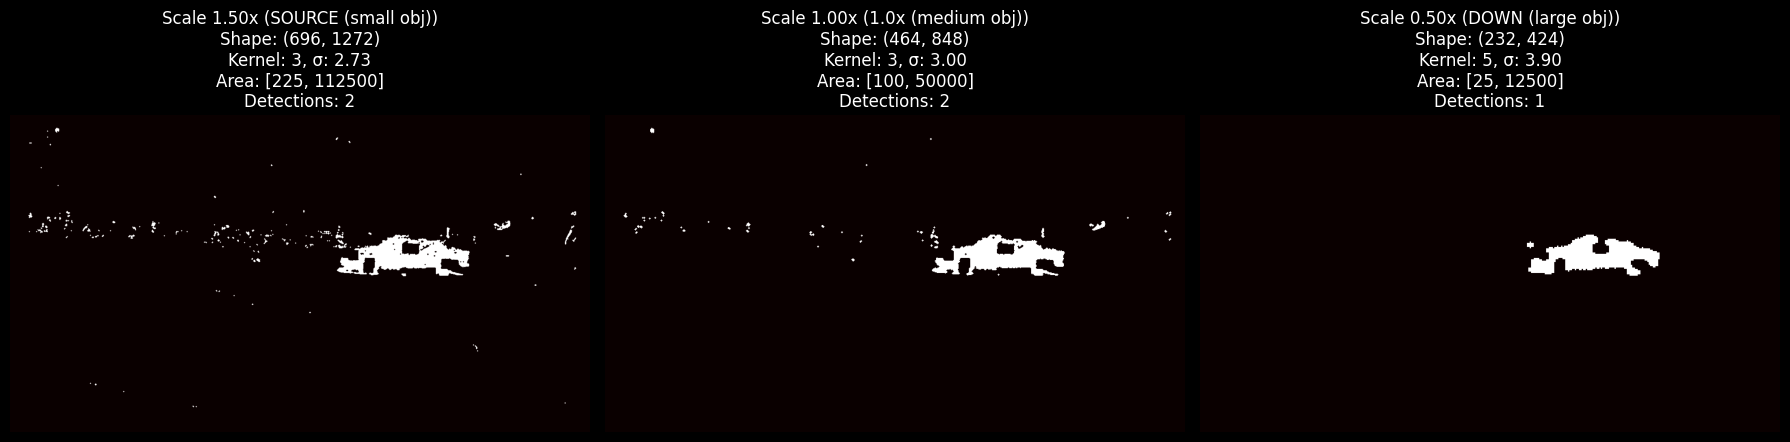

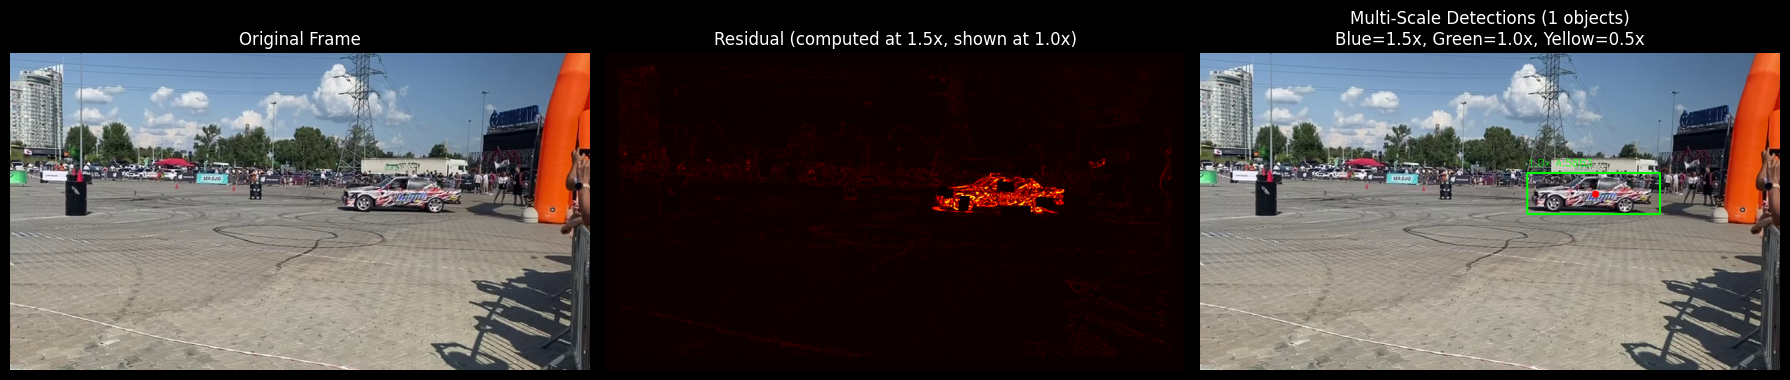

In [10]:
# ============================================
# Visualize pyramid levels for a single frame
# ============================================

def analyze_single_frame(video_path, frame_num=30, 
                         source_scale=SOURCE_SCALE,
                         target_scales=DOWNSCALE_TARGETS):
    """
    Analyze a single frame showing detections at each pyramid level.
    Uses single optical flow at source_scale with downscale pyramid.
    """
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num - 1)
    ret, prev_frame_orig = cap.read()
    ret, curr_frame_orig = cap.read()
    cap.release()
    
    if not ret:
        print(f"Cannot read frame {frame_num}")
        return
    
    # Upscale frames for optical flow
    prev_frame_scaled = upscale_frame(prev_frame_orig, source_scale)
    curr_frame_scaled = upscale_frame(curr_frame_orig, source_scale)
    
    prev_gray_scaled = cv2.cvtColor(prev_frame_scaled, cv2.COLOR_BGR2GRAY)
    curr_gray_scaled = cv2.cvtColor(curr_frame_scaled, cv2.COLOR_BGR2GRAY)
    
    # Track and estimate motion at scaled resolution
    prev_pts = detect_features(prev_gray_scaled)
    old_pts, new_pts, _ = track_features(prev_gray_scaled, curr_gray_scaled, prev_pts)
    
    if old_pts is None or len(old_pts) < 4:
        print("Not enough tracked points")
        return
    
    H, _ = estimate_ego_motion_ransac(old_pts, new_pts)
    
    if H is None:
        print("Could not estimate homography")
        return
    
    # Compute residual at scaled resolution
    warped_prev_scaled = warp_frame(prev_gray_scaled, H)
    valid_mask_scaled = create_valid_warp_mask(warped_prev_scaled, BORDER_MARGIN)
    residual_scaled = compute_residual(curr_gray_scaled, warped_prev_scaled, valid_mask_scaled)
    
    # Multi-scale processing
    detections, level_info = process_multiscale_pyramid(
        residual_scaled, valid_mask_scaled, source_scale, target_scales
    )
    
    # Visualize
    print(f"\n{'=' * 60}")
    print(f"Frame {frame_num} Analysis - Single OF Multi-Scale Pyramid")
    print(f"{'=' * 60}")
    print(f"Source scale: {source_scale}x (OF computed here)")
    print(f"Downscale targets: {target_scales}")
    print(f"Total detections (after NMS merging): {len(detections)}")
    print(f"\nPer-scale breakdown:")
    for info in level_info:
        if info['scale'] == source_scale:
            scale_type = "SOURCE"
        elif info['scale'] == 1.0:
            scale_type = "MEDIUM"
        else:
            scale_type = "DOWNSCALE"
        print(f"  {info['scale']:.2f}x ({scale_type}): {info['shape']} -> "
              f"{info['detections']} raw detections, "
              f"threshold={info['threshold']:.1f}")
    
    # Show pyramid masks
    visualize_pyramid_levels(level_info, f"{PYRAMID_DIR}/pyramid_frame_{frame_num}.png")
    
    # Downscale residual for display
    residual_orig = downscale_to_target(residual_scaled, source_scale, 1.0)
    
    # Show final result
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(cv2.cvtColor(curr_frame_orig, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Frame')
    axes[0].axis('off')
    
    axes[1].imshow(residual_orig, cmap='hot')
    axes[1].set_title(f'Residual (computed at {source_scale}x, shown at 1.0x)')
    axes[1].axis('off')
    
    output = draw_detections(curr_frame_orig, detections)
    axes[2].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'Multi-Scale Detections ({len(detections)} objects)\n'
                      f'Blue={source_scale}x, Green=1.0x, Yellow=0.5x')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/analysis_frame_{frame_num}.png", dpi=150)
    plt.show()

# Analyze a specific frame
analyze_single_frame(VIDEO_PATH, frame_num=30)

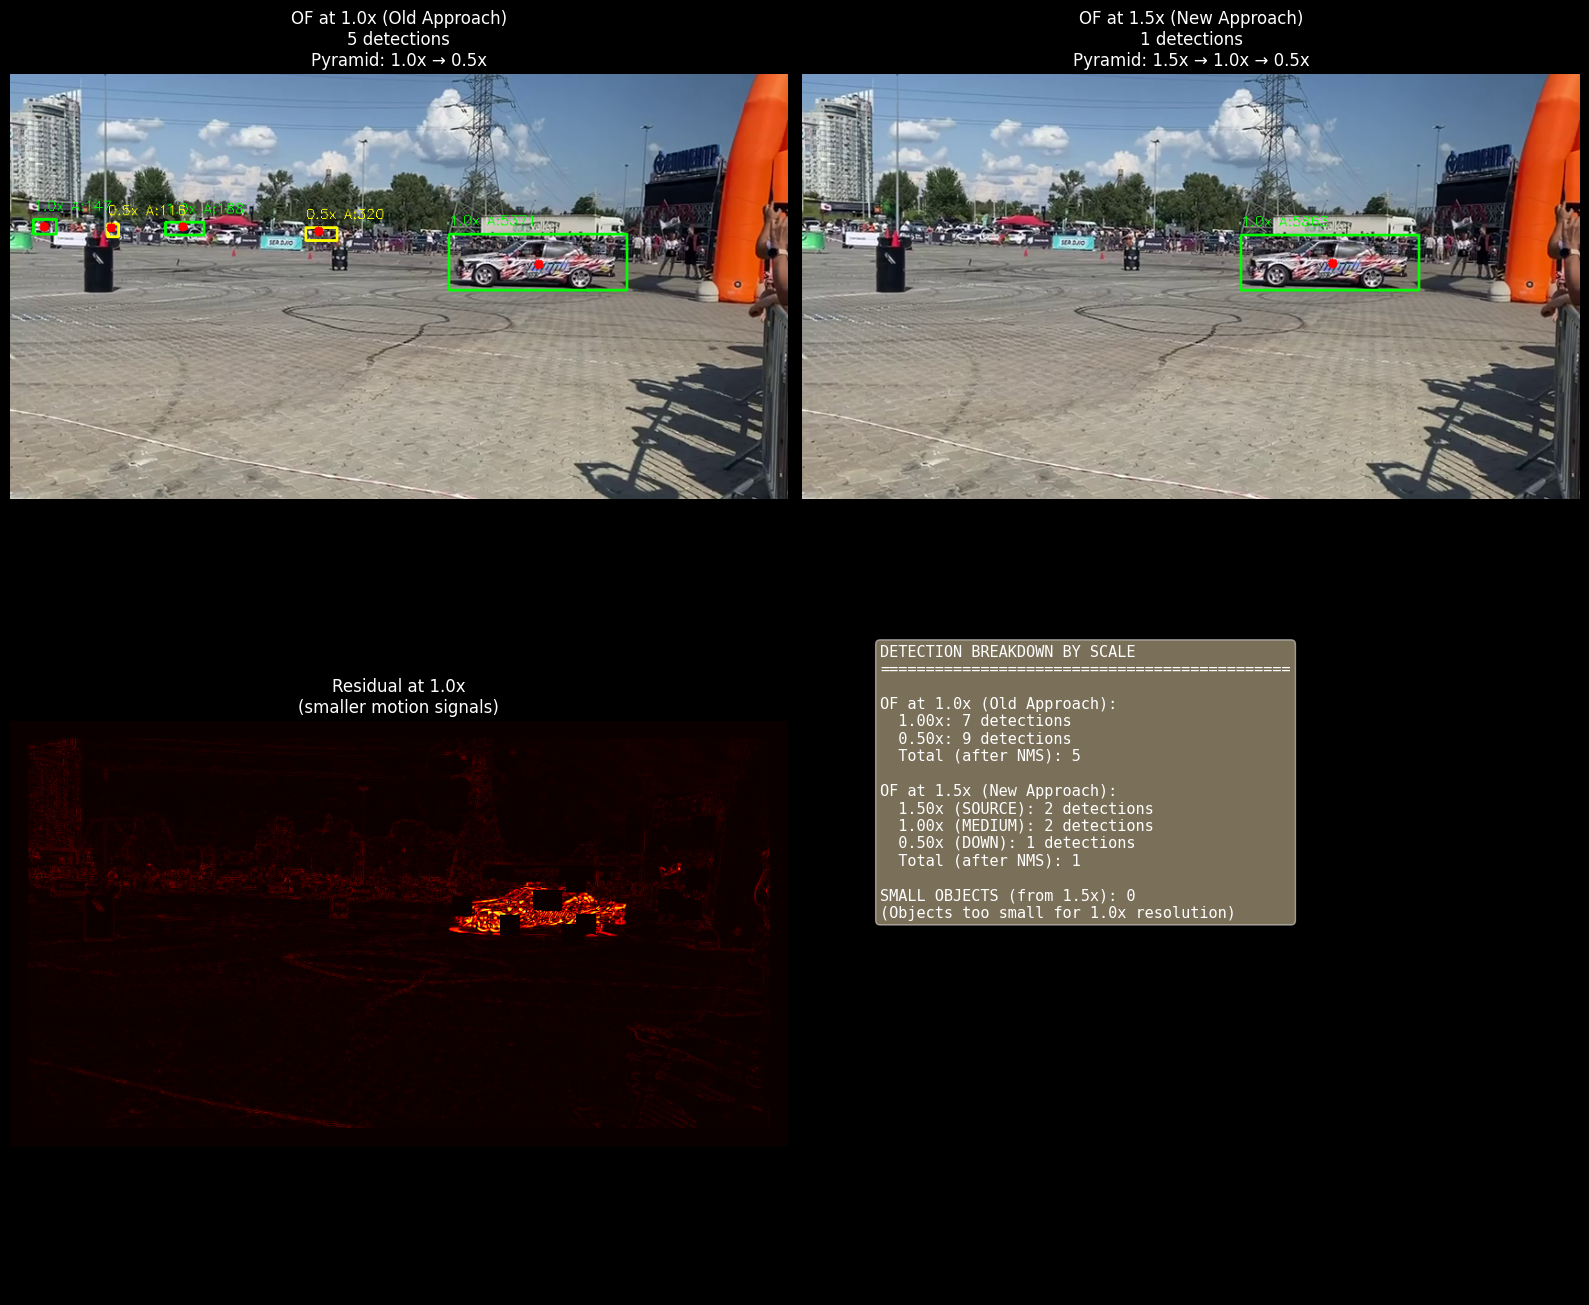


COMPARISON SUMMARY
OF at 1.0x: 5 detections
OF at 1.5x: 1 detections
Improvement: +-4 detections

Small objects from 1.5x scale: 0


In [11]:
# ============================================
# Compare 1.0x OF vs 1.5x OF (source scale) approaches
# ============================================

def compare_source_scales(video_path, frame_num=30):
    """
    Compare optical flow at 1.0x (old approach) vs 1.5x (new approach).
    Shows how upscaling source before OF improves small object detection.
    """
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num - 1)
    ret, prev_frame_orig = cap.read()
    ret, curr_frame_orig = cap.read()
    cap.release()
    
    if not ret:
        print(f"Cannot read frame {frame_num}")
        return
    
    # ========================================
    # Approach 1: OF at 1.0x (old approach)
    # ========================================
    prev_gray_1x = cv2.cvtColor(prev_frame_orig, cv2.COLOR_BGR2GRAY)
    curr_gray_1x = cv2.cvtColor(curr_frame_orig, cv2.COLOR_BGR2GRAY)
    
    # Use original scale parameters
    feature_params_1x = dict(maxCorners=400, qualityLevel=0.01, minDistance=15, blockSize=7)
    lk_params_1x = dict(winSize=(19, 19), maxLevel=3, 
                        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
    
    prev_pts_1x = cv2.goodFeaturesToTrack(prev_gray_1x, **feature_params_1x)
    curr_pts_1x, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray_1x, curr_gray_1x, prev_pts_1x, None, **lk_params_1x)
    
    if status is not None:
        good_old_1x = prev_pts_1x[status.ravel() == 1]
        good_new_1x = curr_pts_1x[status.ravel() == 1]
    
    H_1x, _ = cv2.findHomography(good_old_1x, good_new_1x, cv2.RANSAC, 3.0)
    
    if H_1x is not None:
        warped_1x = cv2.warpPerspective(prev_gray_1x, H_1x, (prev_gray_1x.shape[1], prev_gray_1x.shape[0]))
        valid_mask_1x = create_valid_warp_mask(warped_1x, 20)
        residual_1x = compute_residual(curr_gray_1x, warped_1x, valid_mask_1x)
        
        # Process at 1.0x with downscale to 0.5x
        detections_1x, info_1x = process_multiscale_pyramid(
            residual_1x, valid_mask_1x, 
            source_scale=1.0, 
            target_scales=[0.5]
        )
    else:
        detections_1x = []
        info_1x = []
    
    # ========================================
    # Approach 2: OF at 1.5x (new approach)
    # ========================================
    prev_frame_1_5x = upscale_frame(prev_frame_orig, 1.5)
    curr_frame_1_5x = upscale_frame(curr_frame_orig, 1.5)
    
    prev_gray_1_5x = cv2.cvtColor(prev_frame_1_5x, cv2.COLOR_BGR2GRAY)
    curr_gray_1_5x = cv2.cvtColor(curr_frame_1_5x, cv2.COLOR_BGR2GRAY)
    
    prev_pts_1_5x = detect_features(prev_gray_1_5x)
    old_pts_1_5x, new_pts_1_5x, _ = track_features(prev_gray_1_5x, curr_gray_1_5x, prev_pts_1_5x)
    
    H_1_5x, _ = estimate_ego_motion_ransac(old_pts_1_5x, new_pts_1_5x)
    
    if H_1_5x is not None:
        warped_1_5x = warp_frame(prev_gray_1_5x, H_1_5x)
        valid_mask_1_5x = create_valid_warp_mask(warped_1_5x, BORDER_MARGIN)
        residual_1_5x = compute_residual(curr_gray_1_5x, warped_1_5x, valid_mask_1_5x)
        
        # Process with full pyramid: 1.5x -> 1.0x -> 0.5x
        detections_1_5x, info_1_5x = process_multiscale_pyramid(
            residual_1_5x, valid_mask_1_5x,
            source_scale=1.5,
            target_scales=[1.0, 0.5]
        )
    else:
        detections_1_5x = []
        info_1_5x = []
    
    # ========================================
    # Visualize comparison
    # ========================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # Top left: 1.0x OF result
    output_1x = draw_detections(curr_frame_orig, detections_1x)
    axes[0, 0].imshow(cv2.cvtColor(output_1x, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title(f'OF at 1.0x (Old Approach)\n'
                         f'{len(detections_1x)} detections\n'
                         f'Pyramid: 1.0x → 0.5x')
    axes[0, 0].axis('off')
    
    # Top right: 1.5x OF result
    output_1_5x = draw_detections(curr_frame_orig, detections_1_5x)
    axes[0, 1].imshow(cv2.cvtColor(output_1_5x, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title(f'OF at 1.5x (New Approach)\n'
                         f'{len(detections_1_5x)} detections\n'
                         f'Pyramid: 1.5x → 1.0x → 0.5x')
    axes[0, 1].axis('off')
    
    # Bottom left: Residual comparison
    if H_1x is not None:
        axes[1, 0].imshow(residual_1x, cmap='hot')
        axes[1, 0].set_title('Residual at 1.0x\n(smaller motion signals)')
    else:
        axes[1, 0].set_title('No homography at 1.0x')
    axes[1, 0].axis('off')
    
    # Bottom right: Detection counts
    axes[1, 1].axis('off')
    
    comparison_text = "DETECTION BREAKDOWN BY SCALE\n" + "=" * 45 + "\n\n"
    
    comparison_text += "OF at 1.0x (Old Approach):\n"
    for info in info_1x:
        comparison_text += f"  {info['scale']:.2f}x: {info['detections']} detections\n"
    comparison_text += f"  Total (after NMS): {len(detections_1x)}\n\n"
    
    comparison_text += "OF at 1.5x (New Approach):\n"
    for info in info_1_5x:
        scale_type = "SOURCE" if info['scale'] == 1.5 else ("MEDIUM" if info['scale'] == 1.0 else "DOWN")
        comparison_text += f"  {info['scale']:.2f}x ({scale_type}): {info['detections']} detections\n"
    comparison_text += f"  Total (after NMS): {len(detections_1_5x)}\n\n"
    
    # Count detections from 1.5x scale
    small_obj_detections = [d for d in detections_1_5x if d.get('scale', 1.0) == 1.5]
    comparison_text += f"SMALL OBJECTS (from 1.5x): {len(small_obj_detections)}\n"
    comparison_text += "(Objects too small for 1.0x resolution)"
    
    axes[1, 1].text(0.1, 0.9, comparison_text, transform=axes[1, 1].transAxes,
                    fontsize=11, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/comparison_frame_{frame_num}.png", dpi=150)
    plt.show()
    
    print(f"\n{'=' * 60}")
    print("COMPARISON SUMMARY")
    print(f"{'=' * 60}")
    print(f"OF at 1.0x: {len(detections_1x)} detections")
    print(f"OF at 1.5x: {len(detections_1_5x)} detections")
    print(f"Improvement: +{len(detections_1_5x) - len(detections_1x)} detections")
    print(f"\nSmall objects from 1.5x scale: {len(small_obj_detections)}")

# Run comparison
compare_source_scales(VIDEO_PATH, frame_num=30)

## How Single Optical Flow Multi-Scale Pyramid with EMA Works

### The Key Insight
Instead of computing optical flow at original resolution and then upscaling the residual, we **upscale the source frames first** and compute optical flow at higher resolution. Additionally, we use **EMA (Exponential Moving Average)** to smooth residuals over time.

### Architecture
```
Frame → Upscale 1.5x → Optical Flow → Homography → Residual (1.5x)
                                                        │
                                                   ┌────┴────┐
                                                   │  EMA    │
                                                   │ Accum   │  ← Exponential smoothing
                                                   └────┬────┘
                                                        │
                              ┌─────────────────────────┤
                              │                         │
                         Detect @ 1.5x            Downscale
                         (small objects)          (resize)
                                                        │
                              ┌─────────────────────────┤
                              │                         │
                         Detect @ 1.0x            Downscale  
                         (medium objects)         (resize)
                                                        │
                                                   Detect @ 0.5x
                                                   (large objects)
                                                        │
                                                   NMS Merge
                                                        │
                                               ┌────────┴────────┐
                                               │  Track Manager  │
                                               │  (Kalman+Hung.) │
                                               └────────┬────────┘
                                                        │
                                                   Output Tracks
                                               (with coasting)
```

---

## Track Coasting System

### Overview
Track Coasting keeps tracks alive during brief detection failures by predicting object positions using a Kalman filter motion model.

### Components

#### 1. Kalman Tracker
Constant-velocity Kalman filter for 2D tracking:
- **State**: `[cx, cy, vx, vy]` (position + velocity)
- **Measurement**: `[cx, cy]` (centroid from detection)
- **Prediction**: Used when detection fails (coasting)

#### 2. Track Lifecycle
```
tentative → confirmed → coasting → deleted
    │           │           │
    │           │           └── After MAX_COAST_AGE frames without detection
    │           │
    │           └── Re-acquired detection → back to confirmed
    │
    └── After MIN_HITS detections
```

#### 3. Data Association
Uses **Hungarian algorithm** with cost function combining:
- **Centroid distance** (weight: 0.6)
- **IoU overlap** (weight: 0.4)

### Configuration Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `TRACK_MIN_HITS` | 3 | Detections needed to confirm track |
| `TRACK_MAX_COAST_AGE` | 10 | Max frames to coast without detection |
| `TRACK_MAX_DISTANCE` | 100 px | Max centroid distance for valid match |
| `TRACK_MIN_IOU` | 0.1 | Min IoU for valid match |

### Visual Indicators
- **Green box**: Confirmed track (detected)
- **Yellow dashed box**: Coasting track (predicted position)
- **Blue box**: Tentative track (not yet confirmed)

---

## Multi-Hypothesis Detection

### Overview
Runs detection at multiple sigma thresholds and combines results to recover missed detections and provide confidence scoring.

### Sigma Levels
```python
MULTI_HYPOTHESIS_SIGMAS = [2.0, 2.5, 3.0, 3.5, 4.0]
```

| Sigma | Weight | Sensitivity |
|-------|--------|-------------|
| 2.0 | 0.5 | Very sensitive (more false positives) |
| 2.5 | 0.7 | Sensitive |
| 3.0 | 1.0 | Base threshold |
| 3.5 | 1.2 | Conservative |
| 4.0 | 1.5 | Very conservative (high confidence) |

### Confidence Scoring
Objects detected at multiple sigma levels get higher confidence:
```
confidence = 0.4 × (num_hypotheses / 5) + 
             0.4 × (total_weight / max_weight) +
             0.2 × (best_sigma / 4.0)
```

---

## EMA vs MAX Pooling

| Feature | MAX Pooling | EMA |
|---------|-------------|-----|
| Memory | Buffer of N frames | Single frame |
| Formula | max(last N frames) | α×new + (1-α)×old |
| Decay | Hard cutoff at N frames | Exponential decay |
| Ghosting | None (old frames removed) | Possible (old never fully gone) |
| Best for | Shape recovery | Smooth tracking |
| Tuning | Buffer size (N) | Alpha (α) |

### EMA Formula

```
EMA_t = α × Residual_t + (1-α) × EMA_{t-1}

Where:
  - EMA_t = accumulated residual at time t
  - Residual_t = current frame's residual
  - α (alpha) = weight for new frame (0.0-1.0)
```

### Effect of Alpha (α)

```
α = 0.2 (Low)     α = 0.5 (Medium)   α = 0.8 (High)
┌───────────┐    ┌───────────┐      ┌───────────┐
│ ▒▒▒▒▒▒▒▒▒ │    │ ▒▒▒██▒▒▒  │      │ ░░░██░░░  │
│ Very      │    │ Balanced  │      │ Very      │
│ smooth    │    │           │      │ responsive│
│ Slow      │    │           │      │ More noise│
└───────────┘    └───────────┘      └───────────┘

Effective frames ≈ 2/α - 1:
  - α=0.2 → ~9 frames
  - α=0.4 → ~4 frames
  - α=0.5 → ~3 frames
  - α=0.8 → ~1.5 frames
```

---

## Parameter Scaling

| Scale | Type | Kernel | Sigma | Min Area | Max Area | Best For |
|-------|------|--------|-------|----------|----------|----------|
| 1.5x | SOURCE | 3×3 | ~2.72 | 225 px | 112500 px | Small objects |
| 1.0x | MEDIUM | 3×3 | 3.00 | 100 px | 50000 px | Medium objects |
| 0.5x | DOWN | 5×5 | ~3.90 | 25 px | 12500 px | Large objects |

---

## Configuration Summary

### Core Parameters
```python
EMA_ALPHA = 0.4           # Temporal smoothing weight
SOURCE_SCALE = 1.5        # Upscale before OF
DOWNSCALE_TARGETS = [1.0, 0.5]  # Pyramid levels
```

### Track Coasting
```python
ENABLE_TRACKING = True
TRACK_MIN_HITS = 3        # Hits to confirm
TRACK_MAX_COAST_AGE = 10  # Max coast frames
TRACK_MAX_DISTANCE = 100  # Max match distance
TRACK_MIN_IOU = 0.1       # Min IoU threshold
```

### Multi-Hypothesis
```python
ENABLE_MULTI_HYPOTHESIS = True
MULTI_HYPOTHESIS_SIGMAS = [2.0, 2.5, 3.0, 3.5, 4.0]
HYPOTHESIS_MERGE_IOU = 0.5
```

---

## When to Use Each Feature

**Use EMA when:**
- Memory is limited
- Smooth tracking is more important than shape recovery
- Real-time processing is required

**Use Track Coasting when:**
- Objects may be briefly occluded
- Detection has occasional failures
- You need consistent object IDs across frames

**Use Multi-Hypothesis when:**
- Objects have varying visibility
- You want confidence scores
- False negatives are more costly than false positives